<a href="https://colab.research.google.com/github/ecardoso106/FeedRescue/blob/main/movie_success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project introduction:
Our data analysis aims to help predict and explore film ratings by utilizing multiple different aspects such as meta and IMDB ratings, runtimes, and genres. This project is relevant because utilizing different factors as we will be doing can eventually help predict and dictate a films success even before it hits the box office.

We collected data from Huggingface and Kaggle which sourced their data from IMDB. The one Kaggle dataset contained 1k movies and the two from Huggingface contained 1.5k and 9.84k movies respectively. Totally to over 12k rows of data.


##Any changes since the proposal:
We went through a significant amount of changes throughout the course of this project. At first our scope was fairly broad, we wanted to analyze the success of original films compared to their sequels. However, as we began working with the dataset, we discovered that it lacked the necessary information to accurately identify or compare sequels. This limitation forced us to rethink our approach.

We then narrowed our scope and shifted decided to explore whether movies directed by the same person tended to receive consistent ratings, regardless of the film's genre or series. While this idea seemed promising, we soon learned that it was too narrow and would not provide enough depth or variety for meaningful analysis.

After reassessing the data, we noticed that our dataset contained multiple types of ratings and measures of popularity. This realization led us to shift our focus once again—this time toward using these variables to predict a movie's overall success and popularity. By adapting our research question to fit the data available, we were able to create a more comprehensive and data-driven analysis.

##Data:
To start our analysis and utilizing our data, we had to download them from there respective sources and load them into Google Colab. The top 1000 IMDB dataset that was from Kaggle however, had to first be brought into google sheets and then converted to a CSV file. This file was then brought into colab through mounting our drives. The two huggingface datasets on the other hand, required us to import the load_dataset library, and loaded the dataset using their respective filepath-> load_dataset("filepath").

To actually see our dataset in a more intuitive way, we decided to take another step and import from IPython.display to use the display() to show the data in the typical table format.

We all then prepped our data by removing any missing/NaN values from our datasets, as well as removing any duplicates just to be sure we didn't have multiples of the same movie title. After each change in our main guiding question, we merged and utilized different columns from each dataset to suit our needs.

In [ ]:
!pip install datasets

In [ ]:
!pwd

/content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%ls "/content/drive/MyDrive/imdb_top_1000.csv"

!pwd

/content/drive/MyDrive/imdb_top_1000.csv
/content


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

##Prepping and Cleaning Missing/Duplicates from the Datasets

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()

df_indx_reset = df_clean.reset_index()

df_merge = df_indx_reset[['Series_Title', 'Released_Year', 'IMDB_Rating', 'Gross', 'Meta_score','Genre','Director']]
#rename title column
df_merge.rename(columns={'Series_Title': 'Title'}, inplace=True)

from IPython.display import display

display(df_merge.head(21))

/tmp/ipython-input-3130269566.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merge.rename(columns={'Series_Title': 'Title'}, inplace=True)


,Title,Released_Year,IMDB_Rating,Gross,Meta_score,Genre,Director
0,The Shawshank Redemption,1994,9.3,"28,341,469",80.0,Drama,Frank Darabont
1,The Godfather,1972,9.2,"134,966,411",100.0,"Crime, Drama",Francis Ford Coppola
2,The Dark Knight,2008,9.0,"534,858,444",84.0,"Action, Crime, Drama",Christopher Nolan
3,The Godfather: Part II,1974,9.0,"57,300,000",90.0,"Crime, Drama",Francis Ford Coppola
4,12 Angry Men,1957,9.0,"4,360,000",96.0,"Crime, Drama",Sidney Lumet
5,The Lord of the Rings: The Return of the King,2003,8.9,"377,845,905",94.0,"Action, Adventure, Drama",Peter Jackson
6,Pulp Fiction,1994,8.9,"107,928,762",94.0,"Crime, Drama",Quentin Tarantino
7,Schindler's List,1993,8.9,"96,898,818",94.0,"Biography, Drama, History",Steven Spielberg
8,Inception,2010,8.8,"292,576,195",74.0,"Action, Adventure, Sci-Fi",Christopher Nolan
9,Fight Club,1999,8.8,"37,030,102",66.0,Drama,David Fincher


In [ ]:
# Elizabeth Cardoso is cleaning this data
# Datat is from MongoDB. Highlights would be that it does not have Vote_Average and Vote_Count like other
# data sets so we will have to merge with other data sets or make sure we dont need the columns

from datasets import load_dataset
from IPython.display import display

# load the dataset
ds = load_dataset("MongoDB/embedded_movies")
data = ds["train"]
df = ds["train"].to_pandas()

# get Vote_Average and Vote_Count from the imdb dictionary column
df['Vote_Average'] = df['imdb'].apply(lambda x: x['rating'] if x and pd.notna(x) else None)
df['Vote_Count'] = df['imdb'].apply(lambda x: x['votes'] if x and pd.notna(x) else None)

# Gross and Release_Date dont exist in current dataset!!!!!!
desired_columns = ['title', 'Vote_Average', 'Vote_Count', "metacritic", 'genres']
filtered_df = df[desired_columns]

# rename the columns
filtered_df = filtered_df.rename(columns={
    'title': 'Title',
    'genres': 'Genre',
    'metacritic': 'Popularity'
})

# display data
display(filtered_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sample_mflix.embedded_movies.json:   0%|          | 0.00/42.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1500 [00:00<?, ? examples/s]

,Title,Vote_Average,Vote_Count,Popularity,Genre
0,The Perils of Pauline,7.6,744,NaN,[Action]
1,From Hand to Mouth,7.0,639,NaN,"[Comedy, Short, Action]"
2,Beau Geste,6.9,222,NaN,"[Action, Adventure, Drama]"
3,The Black Pirate,7.2,1146,NaN,"[Adventure, Action]"
4,For Heaven's Sake,7.6,918,NaN,"[Action, Comedy, Romance]"
...,...,...,...,...,...
1495,Postal,4.4,19641,22.0,"[Action, Comedy, Thriller]"
1496,Wild Hogs,5.9,94699,27.0,"[Action, Adventure, Comedy]"
1497,Omkara,8.2,9800,NaN,"[Action, Crime, Drama]"
1498,Day of the Dead,4.5,17177,NaN,"[Action, Horror]"


In [ ]:
# Alejandra is cleaning this dataset
# This code segment showcases the Pablinho movie dataset being cleaned. Duplicate data has been dropped, rows with missing values have been
# deleted, and the index has been reset after cleaning. Only the relevant columns have been selected for analysis.
from datasets import load_dataset

ds = load_dataset("Pablinho/movies-dataset")

data = ds["train"]
df = ds["train"].to_pandas()

from IPython.display import display

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
df_indx_reset = df_clean.reset_index(drop=True)

df_cleaned = df_indx_reset[["Release_Date", "Title", "Popularity", "Vote_Average", "Genre"]].copy()
df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Release_Date"])
df_cleaned["Released_Year"] = df_cleaned["Release_Date"].dt.year

df_cleaned = df_cleaned.drop(columns=["Release_Date"])
display(df_cleaned)

README.md: 0.00B [00:00, ?B/s]

9000plus.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9837 [00:00<?, ? examples/s]

,Title,Popularity,Vote_Average,Genre,Released_Year
0,Spider-Man: No Way Home,5083.954,8.3,"Action, Adventure, Science Fiction",2021
1,The Batman,3827.658,8.1,"Crime, Mystery, Thriller",2022
2,No Exit,2618.087,6.3,Thriller,2022
3,Encanto,2402.201,7.7,"Animation, Comedy, Family, Fantasy",2021
4,The King's Man,1895.511,7.0,"Action, Adventure, Thriller, War",2021
...,...,...,...,...,...
9821,Badlands,13.357,7.6,"Drama, Crime",1973
9822,Violent Delights,13.356,3.5,Horror,2020
9823,The Offering,13.355,5.0,"Mystery, Thriller, Horror",2016
9824,The United States vs. Billie Holiday,13.354,6.7,"Music, Drama, History",2021


## Visualization 1: Average Runtime vs Genre
####By: Kristine Ma


### Hypothesis 1:
Non-fiction/documentaries will have longer runtimes while animated movies will have shorter runtimes.

Films based on real life events and documentaries tend to be longer due to the need of accurately depicting the story/event, which includes many small details and scenes. Animated films on the otherhand are typically targetted towards the younger audience and take longer to make, which means costing more, so those films are shorter to save time while maintaining the viewers focus and attention.

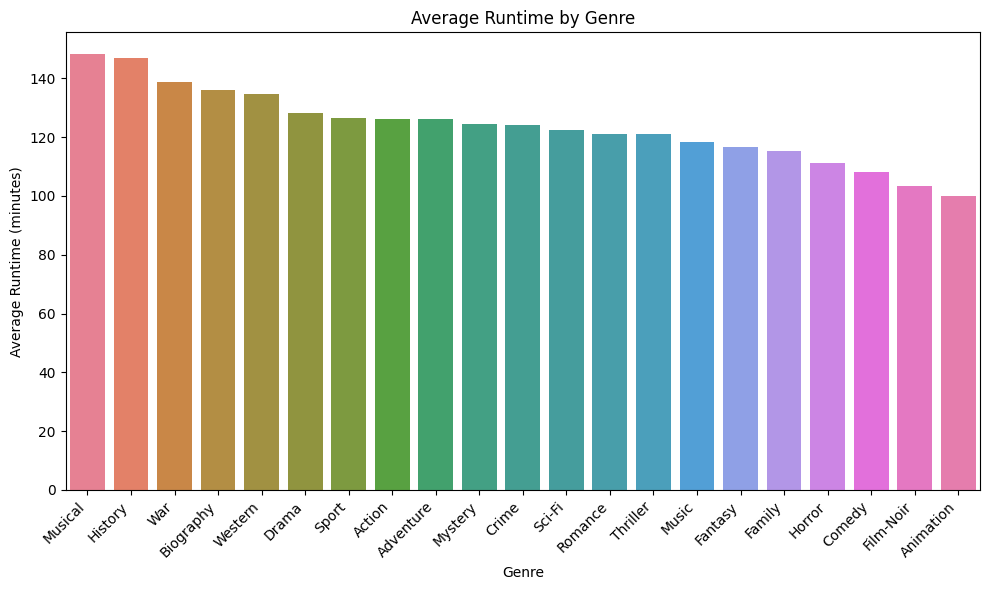

In [ ]:
#Kristine Visualization Genre vs Runtime
from IPython.display import display

df = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')
df = df.dropna().drop_duplicates().reset_index(drop=True)

df_genre = df.copy()

df_genre['Runtime_Minutes'] = df_genre['Runtime'].str.replace(' min', '').astype(float)

df_genre['Genre'] = df_genre['Genre'].str.split(', ')

df_exploded = df_genre.explode('Genre')

avg_runtime = (
    df_exploded.groupby('Genre')['Runtime_Minutes']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=avg_runtime,
    x='Genre',
    y='Runtime_Minutes',
    hue='Genre',
    palette='husl',
    legend=False
)
plt.title('Average Runtime by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Exploratory Data Analysis:
The data visualization supports my hypothesis because the bar graph reveals History, Biography, and Musical as the the top three categories with the highest average runtimes. This makes sense since these genres often have more complex storylines that naturally take more screen time to completely develop. Likewise, Animation has the lowest average runtime, which aligns with my initially thinking as targetting younger audiences require shorter and faster pace storytelling. What is really interesting to note is that the genres that are in the higher half of average runtimes are ones that are typically more serious and dramatic (Ex: War, Sport, Crime, etc.), whereas the lower half of the runtimes are genres with more lighthearted themes (Ex: Romance, Fantasy, Comedy).


## Visualization 2: IMDb Rating Per Genre
####By: Eman Arsham

### Hypothesis 2:
I predict that average IMDb ratings will differ across genres. Some genres—such as drama, film-noir, and mystery—tend to feature more complex narratives and character development, which could lead to higher audience ratings. In contrast, lighter or more formula-based genres like comedy or family films may show slightly lower ratings. However, it is also possible that ratings remain relatively close, since IMDb ratings can be influenced by popularity rather than genre depth alone.

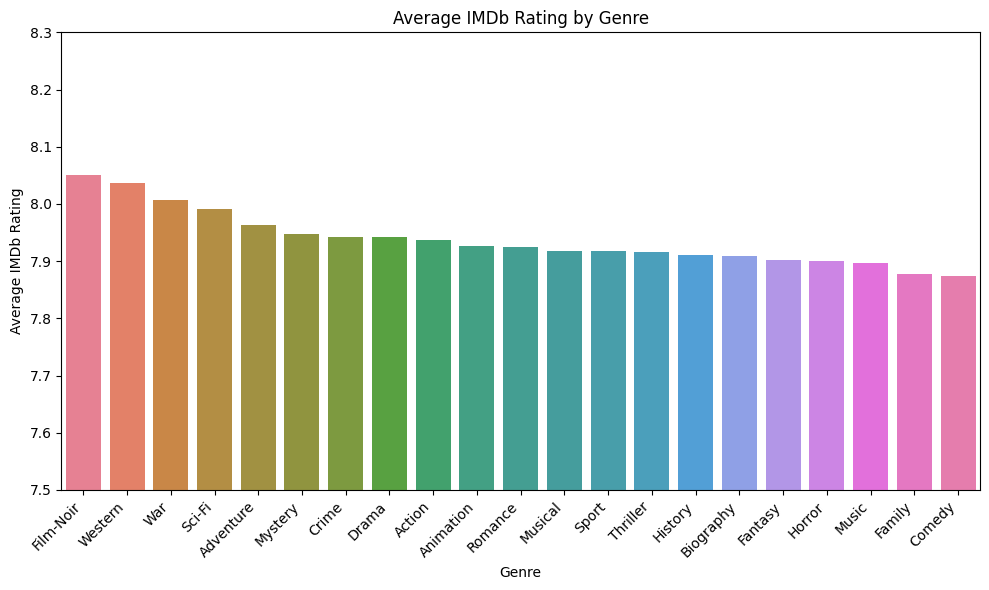

In [ ]:
#Eman Arsham visualizations

df_exploded['IMDB_Rating'] = pd.to_numeric(df_exploded['IMDB_Rating'], errors='coerce')

# Drop rows where IMDB_Rating is NaN
df_exploded = df_exploded.dropna(subset=['IMDB_Rating'])

# Compute average IMDb rating per genre
avg_rating = (
    df_exploded.groupby('Genre')['IMDB_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=avg_rating,
    x='Genre',
    y='IMDB_Rating',
    hue='Genre',
    palette='husl',
    legend=False
)
plt.title('Average IMDb Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average IMDb Rating')
plt.xticks(rotation=45, ha='right')
plt.ylim(7.5, 8.3)  #zoomed in range
plt.tight_layout()
plt.show()



###Exploratory Data Analysis:
The data visualization shows that IMDb ratings across genres are very close to each other, with all averages falling within a narrow range of about 7.58 to 8.05. This means that although a few genres such as Film-Noir, Western, and War appear slightly higher, the overall differences are small.

This result partially supports my hypothesis. I expected genres with deeper narratives, such as Drama or Mystery, to clearly stand out with higher ratings, while lighter genres like Comedy or Family might fall lower. While Comedy and Family are indeed on the lower end, the difference is so small that it does not create a strong separation.

The most important takeaway is how consistent IMDb ratings are across all genres. This suggests that factors other than genre such as general film quality or popularity may influence IMDb ratings more heavily. Even genres aimed at very different audiences end up with similar average scores, which shows that genre alone is not a strong predictor of rating.

##Visualization 3 : Average rating and Popularity ratings per decade
####By: Elizabeth Cardoso

###Hypothesis 3:

USING MEANS FOR THESE GRAPHS (we will show same data but in Medium terms for visualization 4)

I am Grabbing Pablinho movies-dataset specifically focusing on the Population averages and the Vote averages. Our main focus is to compare Average rating and Popularity ratings per decade.

It is reasonable to assume that movie popularity and vote averages will increase over time especially in more recent decades since there is more access to these movies aside from movie theaters (original movie view method).



Average Vote and Popularity by Decade:


/tmp/ipython-input-4283008566.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")


,Decade,Avg_Vote,Avg_Popularity
0,1900,8.00,18.36
1,1920,7.82,17.06
2,1930,7.38,20.77
3,1940,7.34,22.65
4,1950,7.40,21.52
5,1960,7.19,20.03
6,1970,6.78,22.18
7,1980,6.55,23.39
8,1990,6.51,25.35
9,2000,6.39,29.37



Sorted by Decade:


,Decade,Avg_Vote,Avg_Popularity
0,1900,8.00,18.36
1,1920,7.82,17.06
2,1930,7.38,20.77
3,1940,7.34,22.65
4,1950,7.40,21.52
5,1960,7.19,20.03
6,1970,6.78,22.18
7,1980,6.55,23.39
8,1990,6.51,25.35
9,2000,6.39,29.37



Detailed Statistics by Decade:


,Decade,Vote_Average_mean,Vote_Average_median,Vote_Average_count,Popularity_mean,Popularity_median,Popularity_count
0,1900,8.00,8.0,1,18.36,18.36,1
1,1920,7.82,7.9,11,17.06,15.39,11
2,1930,7.38,7.5,33,20.77,16.69,33
3,1940,7.34,7.4,50,22.65,16.37,50
4,1950,7.40,7.3,101,21.52,16.50,101
5,1960,7.19,7.2,205,20.03,16.75,205
6,1970,6.78,7.0,269,22.18,17.57,269
7,1980,6.55,6.6,631,23.39,18.08,631
8,1990,6.51,6.5,1050,25.35,19.17,1050
9,2000,6.39,6.4,2093,29.37,20.35,2093



GRAPH 1: Population and vote results per Decade


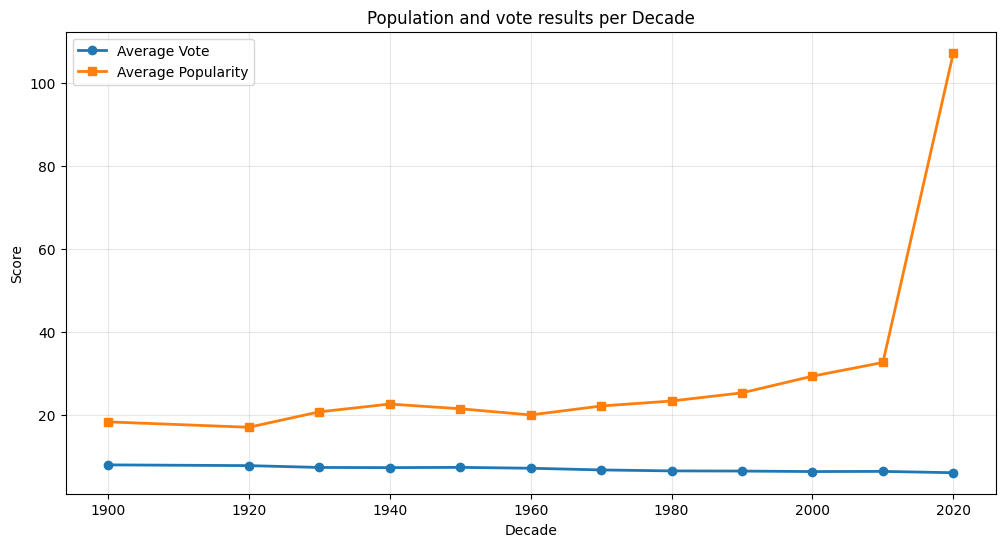


GRAPH 2: Population and vote Averages per Decade


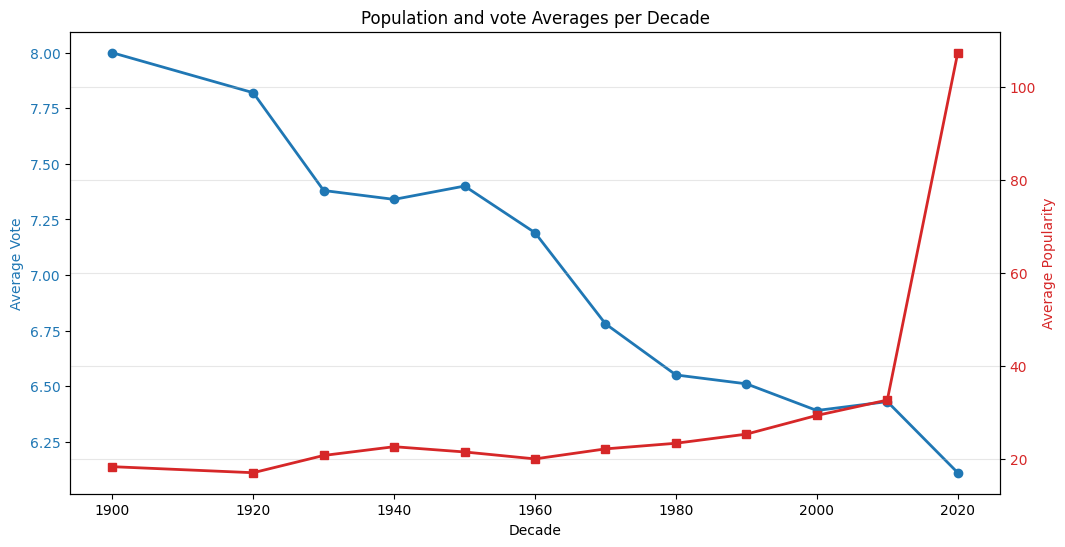


GRAPH 3: Population and movie votes Comparison per Decade Bar Chart


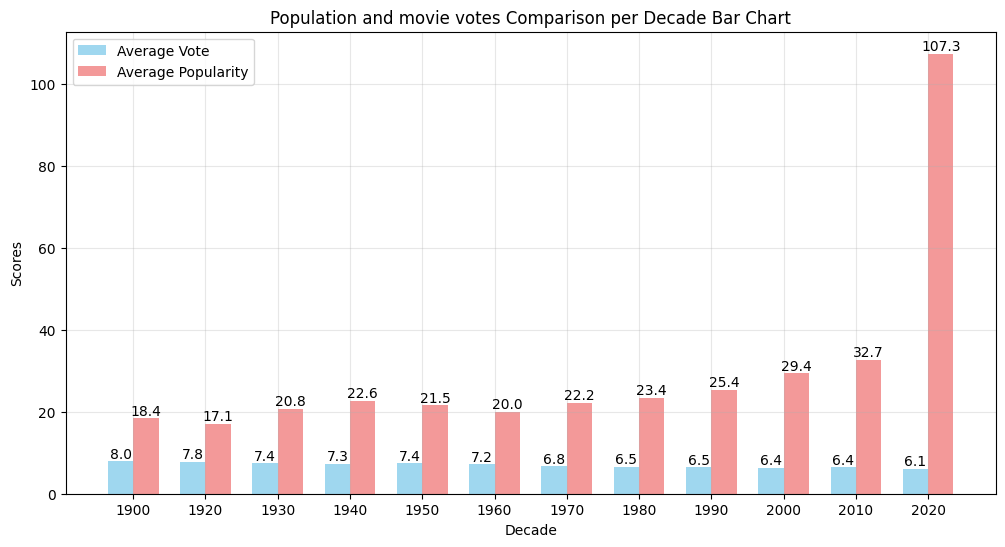


GRAPH 4: Scatter Plot with Regression


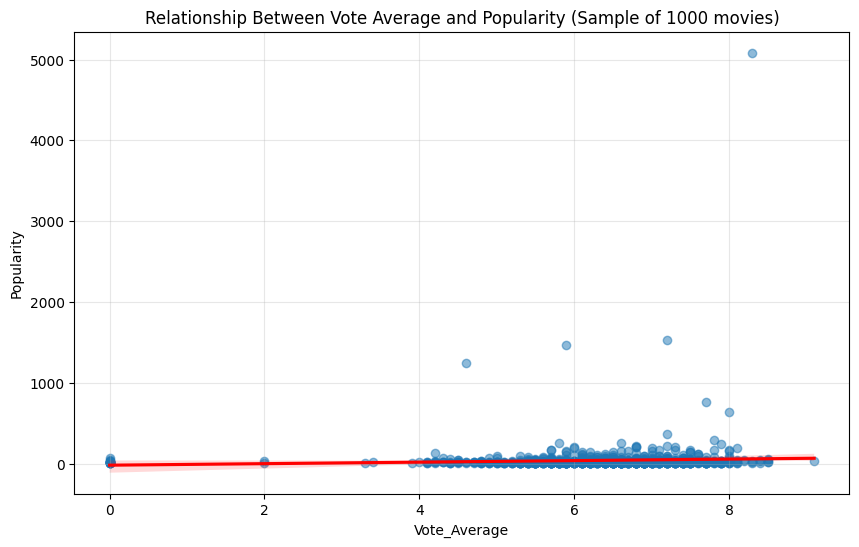


SUMMARY STATISTICS
Total movies in analysis: 9826
Decades covered: 12
Date range: 1902 - 2024


In [ ]:
# Elizabeth Cardoso
# using mean for graphs (we have a right skew ... )

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# load data in
ds = load_dataset("Pablinho/movies-dataset")
data = ds["train"]
df = ds["train"].to_pandas()

# Show the first 10 rows as a nice table
from IPython.display import display

# this data is for the graphs it is used to debug and provide data for the graphs
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
df_indx_reset = df_clean.reset_index(drop=True)

df_cleaned = df_indx_reset[["Release_Date", "Title", "Popularity", "Vote_Average", "Genre"]]

df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Release_Date"])

df_cleaned["Released_Year"] = df_cleaned["Release_Date"].dt.year
df_cleaned = df_cleaned.drop(columns=["Release_Date"])

# making Vote_Average and Popularity to numeric types
df_cleaned["Vote_Average"] = pd.to_numeric(df_cleaned["Vote_Average"], errors="coerce")
df_cleaned["Popularity"] = pd.to_numeric(df_cleaned["Popularity"], errors="coerce")

# cleaning data (we do not want any Nan spots)
df_cleaned = df_cleaned.dropna(subset=["Vote_Average", "Popularity"])

# creating a decade column
df_cleaned['Decade'] = (df_cleaned['Released_Year'] // 10) * 10

# averages per decade
decade_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': 'mean',
    'Popularity': 'mean'
}).round(2).reset_index()

# final column renaming
decade_stats = decade_stats.rename(columns={
    'Vote_Average': 'Avg_Vote',
    'Popularity': 'Avg_Popularity'
})

print("\nAverage Vote and Popularity by Decade:")
display(decade_stats)

# sort by decade makes it easier to read
decade_stats_sorted = decade_stats.sort_values('Decade')
print("\nSorted by Decade:")
display(decade_stats_sorted)

decade_detailed_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': ['mean', 'median', 'count'],
    'Popularity': ['mean', 'median', 'count']
}).round(2)

decade_detailed_stats.columns = ['_'.join(col).strip() for col in decade_detailed_stats.columns.values]
decade_detailed_stats = decade_detailed_stats.reset_index()

print("\nDetailed Statistics by Decade:")
display(decade_detailed_stats)

# GRAPH 1: Bar graph Population and vote averages per Decade
print("\n" + "="*50)
print("GRAPH 1: Population and vote results per Decade")
print("="*50)
plt.figure(figsize=(12, 6))
plt.plot(decade_stats['Decade'], decade_stats['Avg_Vote'], marker='o', label='Average Vote', linewidth=2)
plt.plot(decade_stats['Decade'], decade_stats['Avg_Popularity'], marker='s', label='Average Popularity', linewidth=2)
plt.xlabel('Decade')
plt.ylabel('Score')
plt.title('Population and vote results per Decade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAPH 2: Dual-Axis Line Chart
print("\n" + "="*50)
print("GRAPH 2: Population and vote Averages per Decade")
print("="*50)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Vote Average on left axis
color = 'tab:blue'
ax1.set_xlabel('Decade')
ax1.set_ylabel('Average Vote', color=color)
line1 = ax1.plot(decade_stats['Decade'], decade_stats['Avg_Vote'],
                color=color, marker='o', linewidth=2, label='Average Vote')
ax1.tick_params(axis='y', labelcolor=color)

# second y-axis for Popularity
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Popularity', color=color)
line2 = ax2.plot(decade_stats['Decade'], decade_stats['Avg_Popularity'],
                color=color, marker='s', linewidth=2, label='Average Popularity')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Population and vote Averages per Decade')
plt.grid(True, alpha=0.3)
plt.show()

# GRAPH 3: Side-by-Side Bar Chart
print("\n" + "="*50)
print("GRAPH 3: Population and movie votes Comparison per Decade Bar Chart")
print("="*50)
decades = decade_stats['Decade']
x = np.arange(len(decades))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, decade_stats['Avg_Vote'], width, label='Average Vote', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, decade_stats['Avg_Popularity'], width, label='Average Popularity', alpha=0.8, color='lightcoral')

ax.set_xlabel('Decade')
ax.set_ylabel('Scores')
ax.set_title('Population and movie votes Comparison per Decade Bar Chart')
ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom')

plt.show()

# GRAPH 4: Additional - Scatter Plot with Regression
print("\n" + "="*50)
print("GRAPH 4: Scatter Plot with Regression")
print("="*50)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cleaned.sample(1000), x='Vote_Average', y='Popularity',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship Between Vote Average and Popularity (Sample of 1000 movies)')
plt.grid(True, alpha=0.3)
plt.show()


# some final statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total movies in analysis: {len(df_cleaned)}")
print(f"Decades covered: {len(decade_stats)}")
print(f"Date range: {df_cleaned['Released_Year'].min()} - {df_cleaned['Released_Year'].max()}")

### Exploratory Data Analysis

The data Visualization does not fully support my hypothesis. I assumed that both popularity and Average movie votes will increase in more recent decades. This was true for Popularity votes but not true for voter averages. Vote averages seem to have a downward trend as we go to more recent decades. The change is small but there. Popularity votes on the other hand have increased immensely, especially in the more recent decade.

##Visualization 4 : (same as visualization 3 but now in medium)
####By: Elizabeth Cardoso

###Hypothesis 4:

SAME AS VISUALIZATION 3 BUT NOW USING MEDIUMS FOR THESE GRAPHS

I am Grabbing Pablinho movies-dataset specifically focusing on the Population averages and the Vote averages. Our main focus is to compare Average rating and Popularity ratings per decade.

It is reasonable to assume that movie popularity and vote averages will increase over time especially in more recent decades since there is more access to these movies aside from movie theaters (original movie view method).

MEDIAN Vote and Popularity by Decade:


/tmp/ipython-input-3409243687.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Sorted by Decade:


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Detailed Statistics by Decade (for reference):


,Decade,Vote_Average_mean,Vote_Average_median,Vote_Average_count,Vote_Average_std,Popularity_mean,Popularity_median,Popularity_count,Popularity_std
0,1900,8.00,8.0,1,NaN,18.36,18.36,1,NaN
1,1920,7.82,7.9,11,0.31,17.06,15.39,11,4.26
2,1930,7.38,7.5,33,0.55,20.77,16.69,33,16.70
3,1940,7.34,7.4,50,0.65,22.65,16.37,50,17.31
4,1950,7.40,7.3,101,0.61,21.52,16.50,101,16.45
5,1960,7.19,7.2,205,0.66,20.03,16.75,205,9.54
6,1970,6.78,7.0,269,0.93,22.18,17.57,269,15.45
7,1980,6.55,6.6,631,0.85,23.39,18.08,631,23.51
8,1990,6.51,6.5,1050,0.90,25.35,19.17,1050,18.91
9,2000,6.39,6.4,2093,0.88,29.37,20.35,2093,25.66



GRAPH 1: Median Population and Vote Results per Decade


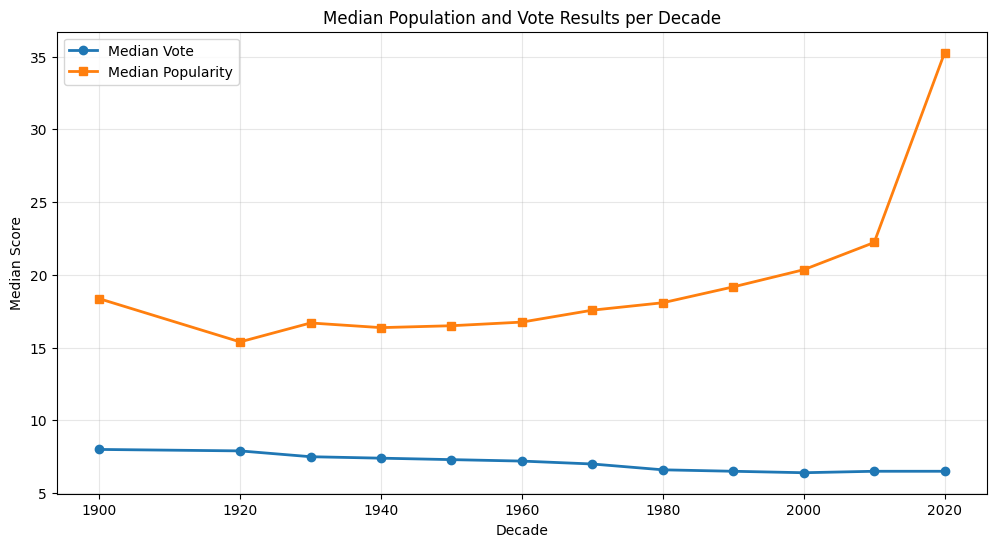


GRAPH 2: Median Population and Vote Results per Decade (Dual Axis)


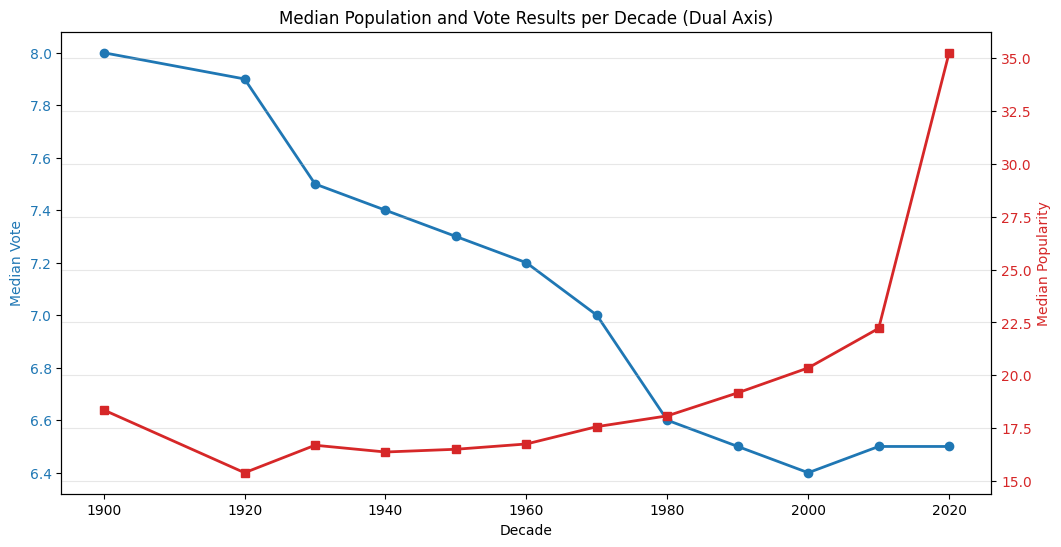


GRAPH 3: Median Population and Movie Votes Comparison per Decade


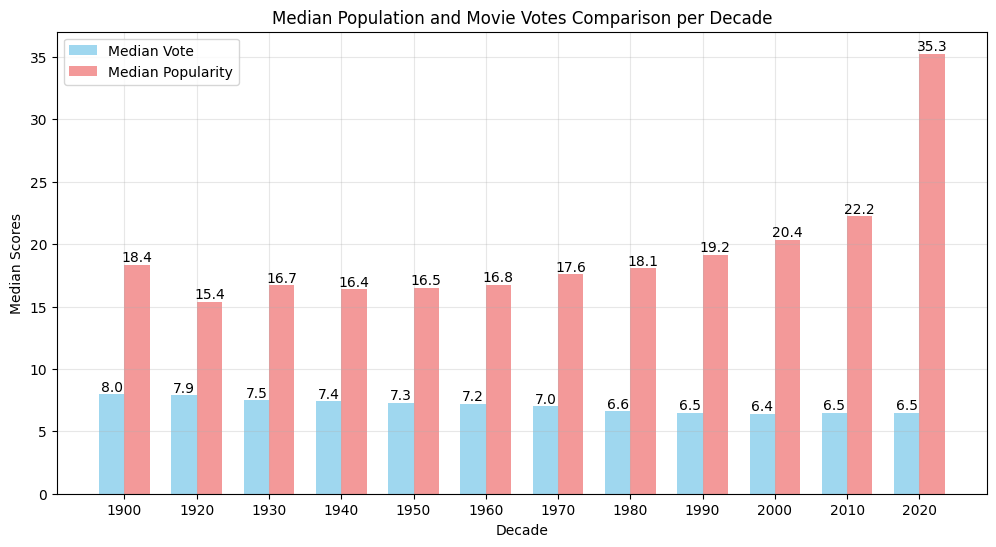


GRAPH 4: Relationship Between Vote Average and Popularity


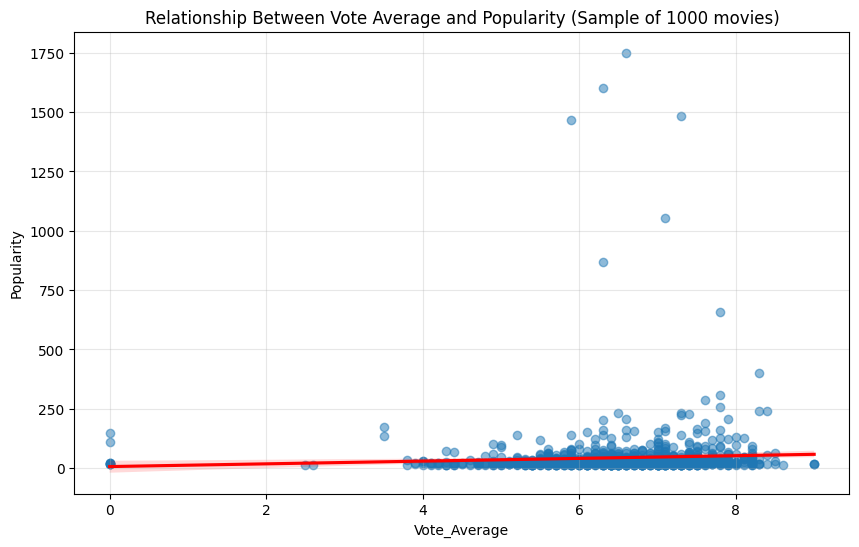


SUMMARY STATISTICS
Total movies in analysis: 9826
Decades covered: 12
Date range: 1902 - 2024
Using MEDIAN values due to data skewness


In [ ]:
# Elizabeth Cardoso
# Using median (Better results less skew now)

from datasets import load_dataset

# Load and data
ds = load_dataset("Pablinho/movies-dataset")
data = ds["train"]
df = ds["train"].to_pandas()

from IPython.display import display

# this data is for the graphs it is used to debug and provide data for the graphs
df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
df_indx_reset = df_clean.reset_index(drop=True)

df_cleaned = df_indx_reset[["Release_Date", "Title", "Popularity", "Vote_Average", "Genre"]]

df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Release_Date"])

df_cleaned["Released_Year"] = df_cleaned["Release_Date"].dt.year
df_cleaned = df_cleaned.drop(columns=["Release_Date"])

# making Vote_Average and Popularity to numeric types
df_cleaned["Vote_Average"] = pd.to_numeric(df_cleaned["Vote_Average"], errors="coerce")
df_cleaned["Popularity"] = pd.to_numeric(df_cleaned["Popularity"], errors="coerce")

# cleaning data (we do not want any Nan spots)
df_cleaned = df_cleaned.dropna(subset=["Vote_Average", "Popularity"])

# creating a decade column
df_cleaned['Decade'] = (df_cleaned['Released_Year'] // 10) * 10

# MEDIANS per decade instead of means
decade_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': 'median',
    'Popularity': 'median'
}).round(2).reset_index()

# renaming coolumns
decade_stats = decade_stats.rename(columns={
    'Vote_Average': 'Median_Vote',
    'Popularity': 'Median_Popularity'
})

# results
print("MEDIAN Vote and Popularity by Decade:")
display(decade_stats)

decade_stats_sorted = decade_stats.sort_values('Decade')
print("\nSorted by Decade:")
display(decade_stats_sorted)

decade_detailed_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': ['mean', 'median', 'count', 'std'],
    'Popularity': ['mean', 'median', 'count', 'std']
}).round(2)

decade_detailed_stats.columns = ['_'.join(col).strip() for col in decade_detailed_stats.columns.values]
decade_detailed_stats = decade_detailed_stats.reset_index()

print("\nDetailed Statistics by Decade (for reference):")
display(decade_detailed_stats)

# GRAPH 1: Line Chart Median Population and Vote Results per Decade
print("\n" + "="*50)
print("GRAPH 1: Median Population and Vote Results per Decade")
print("="*50)
plt.figure(figsize=(12, 6))
plt.plot(decade_stats['Decade'], decade_stats['Median_Vote'], marker='o', label='Median Vote', linewidth=2)
plt.plot(decade_stats['Decade'], decade_stats['Median_Popularity'], marker='s', label='Median Popularity', linewidth=2)
plt.xlabel('Decade')
plt.ylabel('Median Score')
plt.title('Median Population and Vote Results per Decade')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAPH 2: Dual-Axis Median Population and Vote Results per Decade (Dual Axis
print("\n" + "="*50)
print("GRAPH 2: Median Population and Vote Results per Decade (Dual Axis)")
print("="*50)
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Decade')
ax1.set_ylabel('Median Vote', color=color)
line1 = ax1.plot(decade_stats['Decade'], decade_stats['Median_Vote'],
                color=color, marker='o', linewidth=2, label='Median Vote')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Median Popularity', color=color)
line2 = ax2.plot(decade_stats['Decade'], decade_stats['Median_Popularity'],
                color=color, marker='s', linewidth=2, label='Median Popularity')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Median Population and Vote Results per Decade (Dual Axis)')
plt.grid(True, alpha=0.3)
plt.show()

# GRAPH 3: Side-by-Side Bar Chart  Median Population and Movie Votes Comparison per Decade
print("\n" + "="*50)
print("GRAPH 3: Median Population and Movie Votes Comparison per Decade")
print("="*50)
decades = decade_stats['Decade']
x = np.arange(len(decades))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, decade_stats['Median_Vote'], width, label='Median Vote', alpha=0.8, color='skyblue')
bars2 = ax.bar(x + width/2, decade_stats['Median_Popularity'], width, label='Median Popularity', alpha=0.8, color='lightcoral')

ax.set_xlabel('Decade')
ax.set_ylabel('Median Scores')
ax.set_title('Median Population and Movie Votes Comparison per Decade')
ax.set_xticks(x)
ax.set_xticklabels(decades)
ax.legend()
ax.grid(True, alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom')

plt.show()

# not too insightful but will keep for future DO NOT DELETE
# # GRAPH 4: Box Plots to Show Distribution by Decade
# print("\n" + "="*50)
# print("GRAPH 4: Distribution of Votes and Popularity by Decade (Box Plots)")
# print("="*50)

# # Create a sample of decades for better visualization if there are too many
# decade_sample = df_cleaned['Decade'].value_counts().index[:8]  # Top 8 decades by movie count
# df_sample = df_cleaned[df_cleaned['Decade'].isin(decade_sample)]

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# # Box plot for Vote Average
# sns.boxplot(data=df_sample, x='Decade', y='Vote_Average', ax=ax1)
# ax1.set_title('Distribution of Vote Averages by Decade')
# ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
# ax1.grid(True, alpha=0.3)

# # Box plot for Popularity
# sns.boxplot(data=df_sample, x='Decade', y='Popularity', ax=ax2)
# ax2.set_title('Distribution of Popularity by Decade')
# ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45)
# ax2.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# GRAPH 5: Scatter Plot with Regression (using original data, not medians)
print("\n" + "="*50)
print("GRAPH 4: Relationship Between Vote Average and Popularity")
print("="*50)
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cleaned.sample(1000), x='Vote_Average', y='Popularity',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Relationship Between Vote Average and Popularity (Sample of 1000 movies)')
plt.grid(True, alpha=0.3)
plt.show()

# final statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(f"Total movies in analysis: {len(df_cleaned)}")
print(f"Decades covered: {len(decade_stats)}")
print(f"Date range: {df_cleaned['Released_Year'].min()} - {df_cleaned['Released_Year'].max()}")
print(f"Using MEDIAN values due to data skewness")


##Visualization 5: IMDB Rating vs. Meta Score vs. Vote Average
####By: Alejandra Rios

##Hypothesis 5:
There will be no substantial difference between the IMDB rating, meta score, and vote average ratings.

It is reasonable to assume that one's perception of a film will remain consistent regardless of the rating platform or scoring method being used. Each system is based on the same public sentiment, only differing in scales and form of aggregation. With that being said, data analysis can often lead to surprising results. The reason I chose to make this comparison is because I'm curious to see if these rating systems have selection bias. Perhaps those who use the meta score are more critical than those who use IMDB rating.


,Title,IMDB_Rating,Meta_score,Vote_Average
0,the shawshank redemption,9.3,8.0,8.7
1,the godfather,9.2,10.0,8.7
2,the dark knight,9.0,8.4,8.5
3,the godfather: part ii,9.0,9.0,8.6
4,12 angry men,9.0,9.6,8.5
...,...,...,...,...
570,kelly's heroes,7.6,5.0,7.4
571,the jungle book,7.6,6.5,7.3
572,the jungle book,7.6,6.5,6.9
573,the jungle book,7.6,6.5,5.9


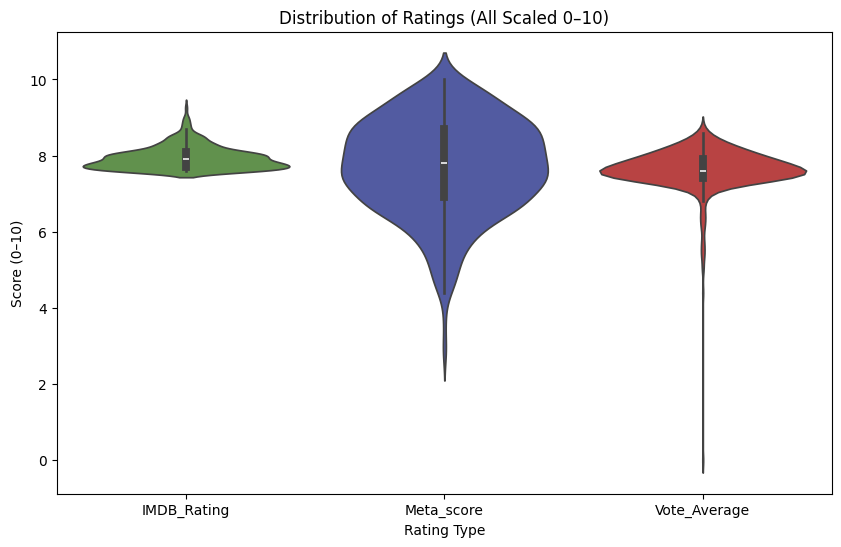

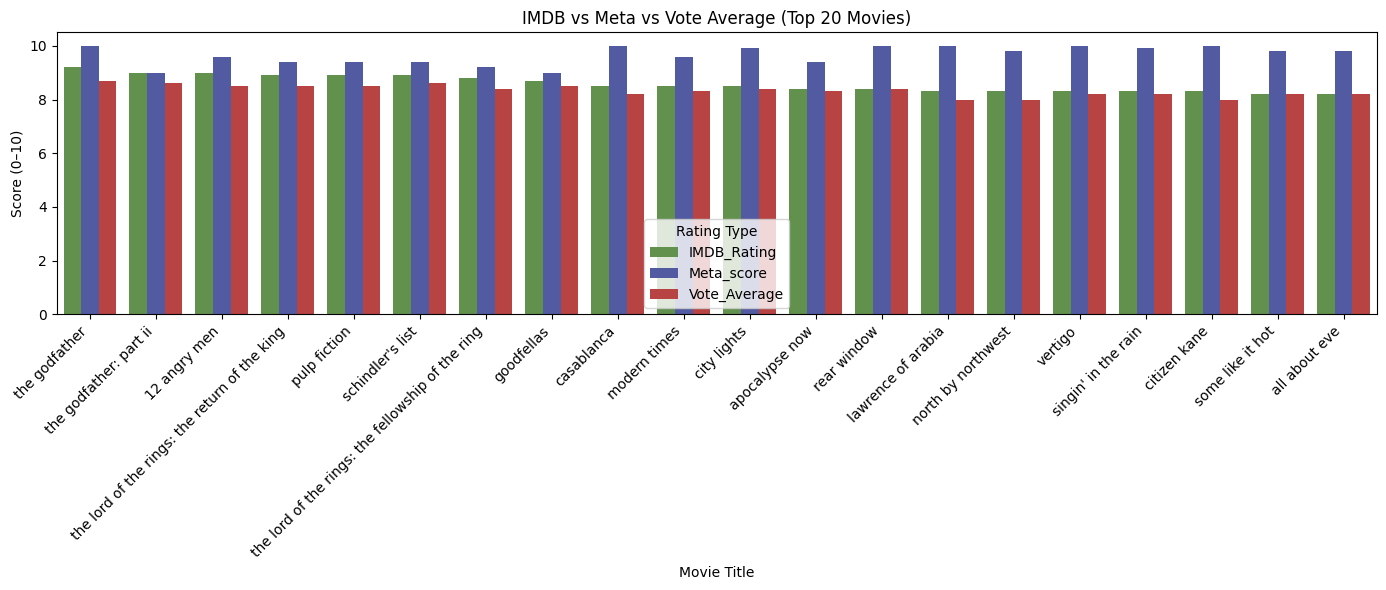

In [ ]:
df_merge['Title'] = df_merge['Title'].str.strip().str.lower()
df_cleaned['Title'] = df_cleaned['Title'].str.strip().str.lower()

merged = pd.merge(
    df_merge,
    df_cleaned,
    on='Title',
    how='inner',
    suffixes=('_imdb', '_pablinho')
)

merged['Meta_score'] = pd.to_numeric(merged['Meta_score'], errors='coerce') / 10
merged['IMDB_Rating'] = pd.to_numeric(merged['IMDB_Rating'], errors='coerce')
merged['Vote_Average'] = pd.to_numeric(merged['Vote_Average'], errors='coerce')

display(merged[['Title', 'IMDB_Rating', 'Meta_score', 'Vote_Average']])

ratings = merged[['Title', 'IMDB_Rating', 'Meta_score', 'Vote_Average']]

ratings_melted = ratings.melt(
    id_vars=['Title'],
    value_vars=['IMDB_Rating', 'Meta_score', 'Vote_Average'],
    var_name='Rating_Type',
    value_name='Score'
)

ratings_melted['Score'] = pd.to_numeric(ratings_melted['Score'], errors='coerce')

custom_palette = {
    'IMDB_Rating': '#5C9C42',
    'Meta_score': '#4551AE',
    'Vote_Average': '#CB3030'
}

plt.figure(figsize=(10,6))
sns.violinplot(data=ratings_melted, x='Rating_Type', y='Score', hue='Rating_Type', palette=custom_palette)
plt.title('Distribution of Ratings (All Scaled 0–10)')
plt.ylabel('Score (0–10)')
plt.xlabel('Rating Type')
plt.show()

print(" ")

top20 = ratings_melted.groupby('Title', as_index=False)['Score'].mean().nlargest(20, 'Score')['Title']
ratings_top20 = ratings_melted[ratings_melted['Title'].isin(top20)]

plt.figure(figsize=(14,6))
sns.barplot(
    data=ratings_top20,
    x='Title',
    y='Score',
    hue='Rating_Type',
    palette=custom_palette
)
plt.title('IMDB vs Meta vs Vote Average (Top 20 Movies)')
plt.ylabel('Score (0–10)')
plt.xlabel('Movie Title')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Rating Type')
plt.tight_layout()
plt.show()


###Exploratory Data Analysis:
My hypothesis was proven false. Both the bar and violin plots show that movies are consistently given a much higher rating through the Meta Score. *Rear Window*, for example, has a 10 rating on Meta, but only an 8 on IMDB and Vote Average. Furthermore, Meta Score has a much wider scoring range than the other two sources. These results suggest that those who leave Meta scores tend to think more critically about their ratings, producing a wider range of scores. They might also enjoy movies at a higher degree, as they also tend to give movies a higher rating.

An issue I had while analyzing the data is that the Meta Score originally was rated out of 100, while IMDB and Vote Average were rated out of 10. In order to get accurate comparisons, I had to normalise the Meta Score by dividing them by 10.

##

## Vizualization 6: Relationship Between Metascore and Vote Average
####By: Krishna Somarapu

###Hypothesis 6:
I believe that movies with higher Metascores (critic ratings) will also have higher Vote Averages (audience ratings). Even though critics and audiences don’t always think the same way, good-quality movies usually appeal to both groups. So I expect to see a positive relationship between the two scores—when one goes up, the other should generally go up too.

Correlation Table:


,Meta_score,Vote_Average
Meta_score,1.000,0.074
Vote_Average,0.074,1.000


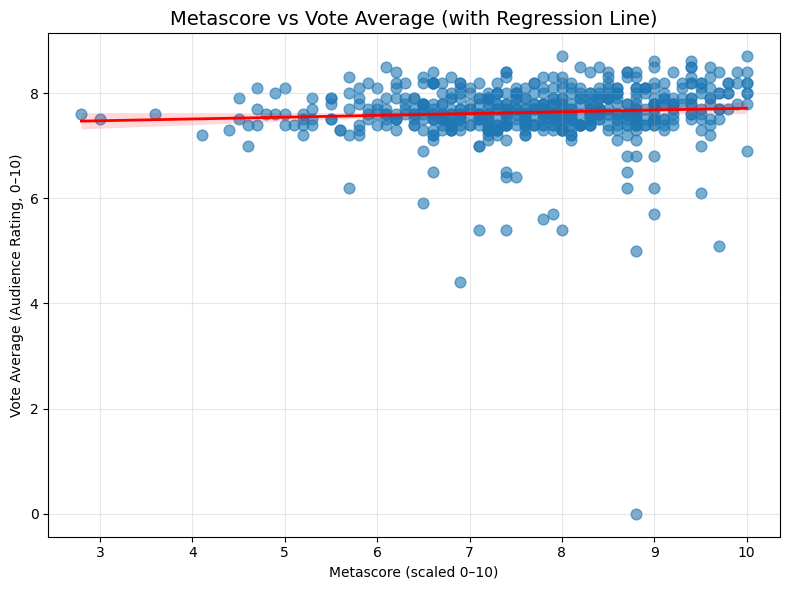

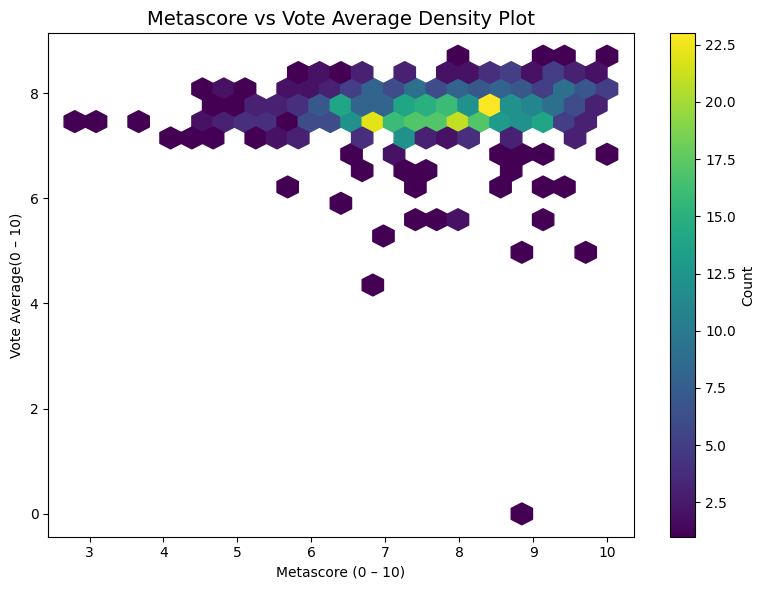

In [ ]:
#  Visualization - Relationship Between Metascore and Vote Average
# krishna

corr1 = merged[['Meta_score', 'Vote_Average']].dropna()


corr_table = corr1.corr()


print("Correlation Table:")

display(corr_table.style.background_gradient(cmap='coolwarm').format("{:.3f}"))

print("\n")
print("\n")

#  Scatter Plot

plt.figure(figsize=(8,6))

sns.regplot(
    data = corr1,
    x='Meta_score',
    y='Vote_Average',
    scatter_kws={'alpha':0.6, 's':60},
    line_kws={'color':'red', 'lw':2}
)

plt.title('Metascore vs Vote Average (with Regression Line)',fontsize=14)

plt.xlabel('Metascore (scaled 0–10)')

plt.ylabel('Vote Average (Audience Rating, 0–10)')

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print("\n")
print("\n")

# Hex Density Plot

plt.figure(figsize=(8,6))

plt.hexbin(
    corr1['Meta_score'],
    corr1['Vote_Average'],
    gridsize = 25,
    cmap='viridis',
    mincnt=1
)

plt.colorbar(label='Count')

plt.title('Metascore vs Vote Average Density Plot',fontsize=14)

plt.xlabel('Metascore (0 – 10)')

plt.ylabel('Vote Average(0 – 10)')

plt.tight_layout()

plt.show()


###Exploratory Data Analysis:
To explore this relationship, I first pulled out the two columns we needed: Meta_score and Vote_Average. I removed any rows with missing values so the results would be clean and consistent. After that, I calculated a basic correlation table to see, in numbers, how closely critic ratings and audience ratings tend to move together.

Next, I created a scatter plot with a regression line. This plot helps show the overall pattern: each point represents a movie, and the line shows the general direction of the relationship. If the line goes upward, it means that when the critic rating is higher, the audience rating also tends to be higher. The spread of the points around that line gives a good sense of how strong or weak that connection is.

Finally, I made a hexbin density plot to get a clearer picture of where most movies fall. When a lot of points overlap, it’s hard to see patterns, so the hexbin plot groups them into colored bins. This helps highlight where the largest clusters of movies are. If the densest area forms a diagonal upward shape, it suggests that many movies with strong critic reviews also receive strong audience ratings. Together, these visuals and the correlation number give a simple but clear view of the relationship.

##ML Analysis 1: TFIDF + SVM
For this ML analysis, we used TF IDF (Term Frequency Inverse Document Frequency) and a SVM model to parse the movie's overview and predict the vote average associated with the respective movie.

The baseline model produced a MAE of 0.692 and an RMSE of 1.007, while the TF-IDF + SVM model resulted in a MAE of 0.727 and an RMSE of 1.041. These results show that the baseline model using numeric inputs such as popularity and vote count performed slightly better than the text based input from the movie overview TF-IDF + SVM model. Since both the MAE and RMSE increased in the TF-IDF model, this indicates that the average prediction error and the overall distance between predicted and actual ratings were larger when using movie overviews as input. In other words, this showed us that text features alone were less effective at predicting vote averages compared to the numeric input baseline.

####By: Kristine Ma & Eman Arsham

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

#Normalizing the data
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Popularity']   = pd.to_numeric(df['Popularity'], errors='coerce')

# Clean up Vote_Count (often formatted like "8,940" or with text)
if df['Vote_Count'].dtype == 'object':
    df['Vote_Count'] = (
        df['Vote_Count']
        .astype(str)
        .str.replace(',', '', regex=False) # remove commas
        .str.extract(r'(\d+)', expand=False) # keep only digits
    )
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')

df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Year'] = df['Release_Date'].dt.year

df['Overview'] = df['Overview'].fillna('')
df['Genre'] = df['Genre'].fillna('')
df['Original_Language'] = df['Original_Language'].fillna('unknown')

df = df.dropna(subset=['Vote_Average']).reset_index(drop=True)

target = 'Vote_Average'
y = df[target].values
X = df

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

def report(name, y_true, y_pred, store=None):
    """Print and store performance metrics for each model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    row  = dict(Model=name, MAE=mae, RMSE=rmse, R2=r2)
    if store is not None: store.append(row)
    print(f"{name:>30} MAE={mae:.3f}  RMSE={rmse:.3f}")

results = []

# Baseline: SVM on numeric-only features
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

num_cols = ['Popularity', 'Vote_Count', 'Year']

num_svm = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),                  # normalize scale
    ("svm",    SVR(kernel='rbf', C=1.0, gamma='scale'))  # SVM regression
])

# Train and predict
num_svm.fit(X_train[num_cols], y_train)
y_pred_num = num_svm.predict(X_test[num_cols])
report("Baseline: Numeric SVM Regression:", y_test, y_pred_num, results)



# TF-IDF + SVM model
text_svm = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1,2),
        min_df=2
    )),
    ("svm", SVR(kernel='rbf', C=1.0, gamma='scale'))  # nonlinear regression
])

# Train on movie overviews
text_svm.fit(X_train['Overview'], y_train)

# Predict on test set
y_pred_text = text_svm.predict(X_test['Overview'])
report("Movie Overview Only TF-IDF + SVM:", y_test, y_pred_text, results)

Baseline: Numeric SVM Regression: MAE=0.692  RMSE=1.007
Movie Overview Only TF-IDF + SVM: MAE=0.727  RMSE=1.041


##ML Analysis 2:
In our second ML model, we used a Random Forest Regressor to predict a movie’s IMDB rating. We combined data from all three datasets and cleaned the columns so we could use the same features across everything. Our model used several numeric features like meta score,gross,popularity,vote count, release year, and the final vote average. We also included the movie’s Director as a categorical feature and converted it using One-Hot Encoding so the model could understand it. Random Forest was a good choice because it can handle many different types of features and find patterns even when the relationships are not simple.

After training the model, we checked the results using MSE and R². The model did a pretty good job and showed that using many features together gives better predictions. Including the director also helped, because some directors consistently make higher-rated films. Overall, this model showed that combining numeric and categorical data makes it easier to predict movie success compared to using only one type of feature.

####By: Elizabeth Cardoso, Alejandra Rios, & Krishna Somarapu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

#clean titles
def clean_title(t):
    return t.strip().lower() if isinstance(t, str) else None

df_merge['Title'] = df_merge['Title'].apply(clean_title)
filtered_df['Title'] = filtered_df['Title'].apply(clean_title)
df_cleaned['Title'] = df_cleaned['Title'].apply(clean_title)

df_merge['Released_Year'] = pd.to_numeric(df_merge['Released_Year'], errors='coerce')
df_cleaned['Released_Year'] = pd.to_numeric(df_cleaned['Released_Year'], errors='coerce')

#merge kaggle and pablinho
merged = pd.merge(
    df_merge,
    df_cleaned[['Title','Released_Year','Popularity','Vote_Average','Genre']],
    on=['Title','Released_Year'],
    how='left',
    suffixes=('_kag', '_pab')
)

#merge imbedded movies
merged = pd.merge(
    merged,
    filtered_df[['Title','Vote_Average','Vote_Count','Popularity','Genre']],
    on='Title',
    how='left',
    suffixes=('_pab2', '_emb')
)

#helper to safley get columns
def get_col_safe(df, col, length):
    if col in df.columns:
        return df[col]
    else:
        return pd.Series([float('nan')] * length)

n = len(merged)

#safe measures
Popularity_emb  = get_col_safe(merged, 'Popularity_emb', n)
Popularity_pab  = get_col_safe(merged, 'Popularity', n)
Popularity_orig = get_col_safe(merged, 'Popularity', n)

merged['Popularity_Final'] = Popularity_emb.fillna(Popularity_pab).fillna(Popularity_orig)

VoteAvg_emb  = get_col_safe(merged, 'Vote_Average_emb', n)
VoteAvg_pab  = get_col_safe(merged, 'Vote_Average', n)
VoteAvg_orig = get_col_safe(merged, 'Vote_Average', n)

merged['Vote_Average_Final'] = VoteAvg_emb.fillna(VoteAvg_pab).fillna(VoteAvg_orig)

Genre_kag  = get_col_safe(merged, 'Genre_kag', n)
Genre_pab  = get_col_safe(merged, 'Genre_pab', n)
Genre_emb  = get_col_safe(merged, 'Genre_emb', n)
Genre_orig = get_col_safe(merged, 'Genre', n)

merged['Genre_Final'] = Genre_kag.fillna(Genre_pab).fillna(Genre_emb).fillna(Genre_orig)

#cleaning
def clean_numeric(col):
    merged[col] = merged[col].replace(r'[\$,]', '', regex=True)
    merged[col] = pd.to_numeric(merged[col], errors='coerce')

numeric_cols = [
    'Meta_score','Gross','Vote_Count',
    'Popularity_Final','Vote_Average_Final'
]

for col in numeric_cols:
    if col in merged.columns:
        clean_numeric(col)

# Essential rows only
merged = merged.dropna(subset=[
    'Meta_score','Released_Year','Gross','Popularity_Final',
    'Vote_Average_Final','Vote_Count','IMDB_Rating'
])

#ml model
X = merged[['Meta_score','Released_Year','Gross','Popularity_Final',
            'Vote_Average_Final','Vote_Count','Director']]
y = merged['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Director'])
], remainder='passthrough')

model = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestRegressor(n_estimators=400, random_state=42))
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MAE: 0.05234090909091226
MSE: 0.005341948863636412
R2: 0.9288132365088099


##Reflection:

1. What is the most challenging part of the project that you've encountered so far?

The most challenging part of the project so far was finalizing our problem statement and guiding question. This beginning stage required significant adaptiblity and collaboration as a team, since our initial ideas always seemed very promising but only to later reveal limitations once we started trying to clean the data. Each time we realized we couldn't move forward with our data due to it not working in our favor with the problem statement, we had to return back to the beginning and fix our question because we knew the datasets had very relevant and useable data. Through multiple rounds of revision, discussion, and feedback, we gradually refined our focus into a question that was both meaningful and feasible within the constraints of our data. This process was time consuming and made us panic quite often but ultimately strengthened our understanding of the project's direction and the importance of aligning our analytical goals with the data resources we had.

2. What are your initial insights?

After finalizing our problem statement on how we might utilize movie data to predict a film's success or ratings and cleaning our dataset to remove irrelevant or redundant information, we drew on prior knowledge from studying Academy Award winners. We noticed a consistent pattern that films with more complex and emotionally deep narratives, like war and drama, tend to receive higher ratings and greater critical acclaim. This lead us to hypothesize that a films genre statistically had great impact on a movie's success.

3. Are there any concrete results you can show at this point? If not, why not?

At this moment, we have some concrete results to show though we are still in the process of further testing other variables to see which factor(s) have the best indicator for a film's rating. Through our results, we found our hypothesis was supported, in which genres akin to more darker and complex narratives often have a higher average rating than lighthearted films.

4. Going forward, what are the current biggest problems you're facing?

Right now our biggest challenge is figuring out which variables across all three datasets are the most reliable and useful. Since each dataset formats its information differently it takes a lot of time to clean, merge, and standardize everything so that our results stay accurate. We are also still learning which features actually matter for predicting a movie’s success. Another challenge is choosing the right modeling approach because our data includes text, numbers, and categories, and each one needs to be handled differently.

5. Do you think you are on track with your project? If not, what parts do you need to dedicate more time to?  

Yes, we believe we are on track. We successfully cleaned and organized our datasets, created multiple visualizations, and began building machine learning models to test our hypotheses. Our visualizations are revealing meaningful trends that support the direction of our analysis, and our ML models are already producing measurable results.

The main area that will require more time is the modeling phase. We need to refine our model inputs, compare performance across different modeling techniques, and decide which features give us the strongest predictive power. We also want to improve the clarity of our explanations for each visualization and ensure that they tie directly back to our guiding question. With more time, we hope to strengthen the connection between our visual findings and our predictive analysis.

6. Given your initial exploration of the data, is it worth proceeding with your project, why? If not, how will you move forward (method, data etc)?

Yes, it is absolutely worth continuing the project. Our datasets provide a wide variety of rating and popularity metrics that allow us to explore movie success from several angles. Our early visualizations reveal interesting but subtle patterns in genre, runtime, and average ratings that justify deeper exploration. The fact that ratings remain close across genres suggests that additional variables are influencing audience opinion, which strengthens our motivation to explore features like popularity, metascore, and text descriptions through machine learning.

The diversity of the datasets also gives us flexibility. If one dataset lacks a particular feature, another dataset can help fill in those gaps. This increases our confidence that we can produce strong and meaningful predictive results. Since we already identified consistent trends and started building viable ML models, moving forward with the project is both practical and promising.

##Next Steps:
Concrete plans and goals for the next month
Moving forward, our main goal is to continue refining our analysis and begin strengthening the predictive side of our project. Now that each group member has completed at least one visualization and explored a specific aspect of the data, our next step is to finalize all visualizations, clean up the interpretations, and make sure they connect clearly back to our guiding question about predicting movie success.

We also plan to focus more heavily on our machine learning models. This includes deciding which features are most meaningful, testing multiple model types, comparing their performance, and making adjustments based on what the data shows. Since we are working with text, numeric, and categorical data from multiple sources, we want to spend extra time making sure our preprocessing pipelines are consistent and reliable.

As we move forward, we will continue dividing the workload evenly, reviewing each other’s work, and meeting regularly to check that our results and explanations are aligned. Once our analyses are fully complete, we will shift our attention to writing the final report, organizing our presentation, and making sure all parts of the project flow together smoothly.

Overall, our next steps involve completing the remaining visualizations, finalizing our ML models, and pulling all results together into a clear and cohesive final project.

## Visualization: IMDb Rating vs Popularity (Scatter + Regression)
####By: Eman Arsham

### Hypothesis:

I predict that movies with higher popularity scores will generally have higher IMDb ratings. Since popularity often reflects visibility, marketing, and audience reach, it makes sense that well-known movies would also receive more positive ratings. However, I also expect there to be some variation because popularity can come from hype, controversy, or trends that don’t always align with actual film quality.
Popularity is one of the features used later in our machine learning models. This plot helps determine whether popularity is a meaningful predictor of IMDb rating something that directly supports and validates our model's input features.

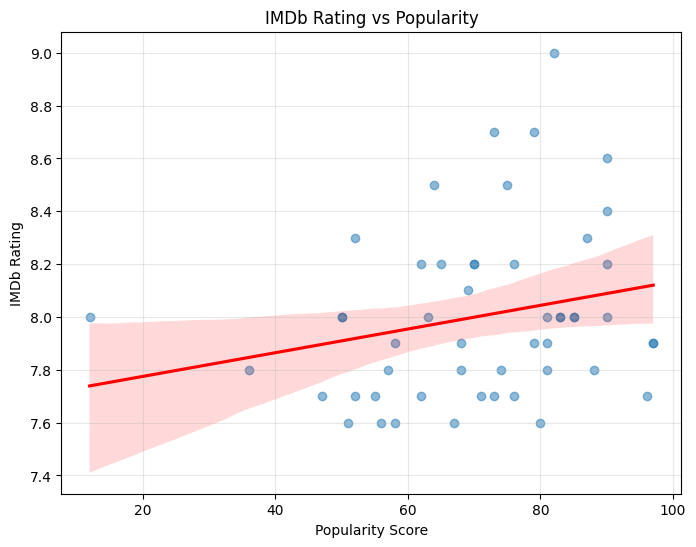

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=merged,
    x='Popularity_Final',
    y='IMDB_Rating',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title('IMDb Rating vs Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('IMDb Rating')
plt.grid(True, alpha=0.3)
plt.show()


### Exploratory Data Analysis:

The scatter plot shows a slight upward trend, confirmed by the regression line. This indicates that popularity does have a positive relationship with IMDb rating, meaning more popular movies tend to receive higher audience ratings. However, the wide spread of points shows that popularity alone is not a strong predictor many moderately popular films receive high ratings, and some highly popular films have only average ratings.
This aligns with the idea that movie success is influenced by multiple factors and supports why combining several features in our ML models yields better predictions.

##Visualization: Distribution of Audience Ratings by Decade (Boxplot)
####By: Eman Arsham

###Hypothesis:

I expect older movies to have higher average audience ratings because the films that remain culturally relevant are typically strong classics. Over time, poorly rated older movies fade out of public attention, leaving a more curated set of titles. In contrast, newer decades likely contain a wider mix of both highly rated films and lower budget or niche productions, leading to more variation.
Our ML models include Released_Year as one of the features. This plot helps us understand whether movie age has a noticeable impact on audience ratings and whether this feature contributes meaningful signal to prediction.

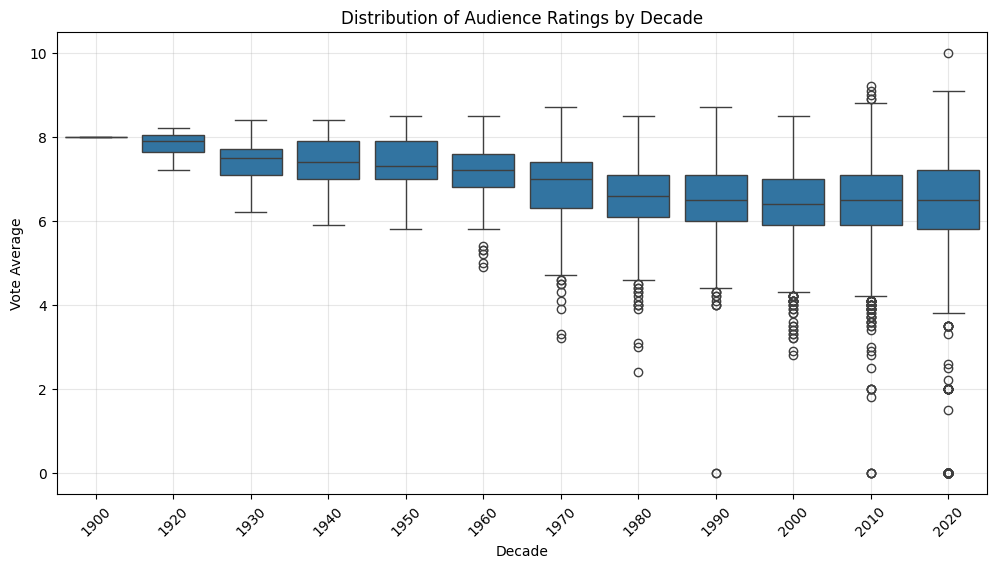

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_cleaned,
    x='Decade',
    y='Vote_Average'
)
plt.title('Distribution of Audience Ratings by Decade')
plt.xticks(rotation=45)
plt.ylabel('Vote Average')
plt.grid(True, alpha=0.3)
plt.show()


###Exploratory Data Analysis:

The boxplot reveals that older decades especially the 1930s through the 1960s tend to have higher medians and tighter rating distributions, supporting the idea that older, surviving films are generally well reviewed classics. Newer decades show much wider spreads, with more low rated films and greater variability.
This suggests that release year carries some information about rating patterns, but the relationship is not strong enough on its own to predict a rating. This helps explain why Released_Year had limited influence in our ML models.

##Visualization: Correlation Heatmap of Movie Features
####By: Eman Arsham

###Hypothesis:

Since IMDb rating, vote average, and metascore all measure aspects of audience or critic sentiment, I expect these variables to show strong positive correlations. On the other hand, features like release year or gross may have weaker or more complex relationships.

This Visualization is important because the heatmap directly supports our machine learning work. It allows us to:

*   identify which features are useful predictors
*   understand how strongly variables relate
*  justify why these features were included in the ML models





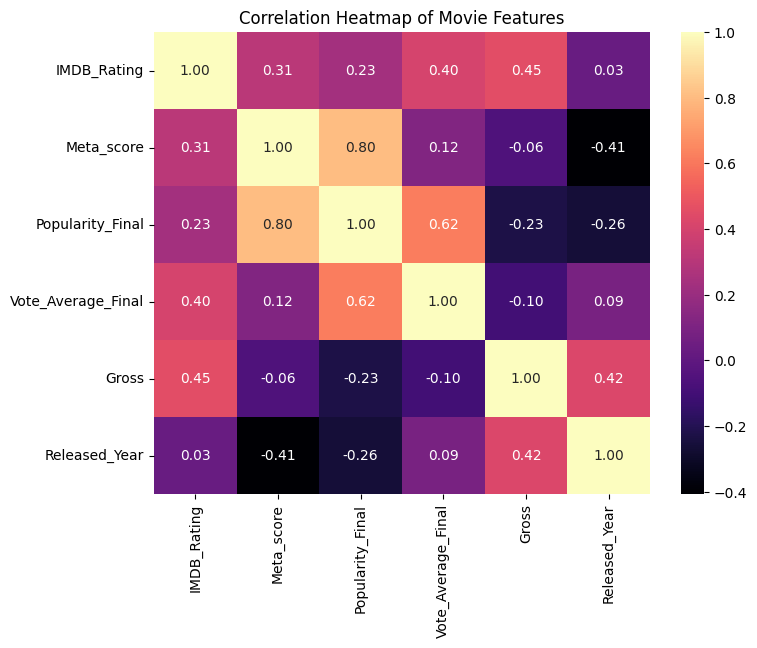

In [ ]:
corr_cols = ['IMDB_Rating','Meta_score','Popularity_Final','Vote_Average_Final','Gross','Released_Year']
corr_matrix = merged[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation Heatmap of Movie Features')
plt.show()

####Exploratory Data Analysis:

The heatmap reveals several meaningful relationships between the movie features we used in our modeling. IMDb Rating shows moderate positive correlations with both Vote_Average_Final (0.40) and Gross revenue (0.45), suggesting that films which receive stronger audience ratings or perform well financially tend to also have higher IMDb scores. Meta Score has a very strong relationship with Popularity_Final (0.80), which indicates that movies that receive higher critic scores also tend to attract more public attention. Meanwhile, Release Year shows very weak or near-zero correlations with most rating variables, reinforcing our earlier findings that the age of a film does not significantly influence its rating once other factors are considered. Overall, these patterns validate our feature selection and help explain why models like Random Forest perform well there are multiple overlapping and nonlinear interactions between these variables that simple linear relationships cannot fully capture.

##ML Analysis: Linear Regression on Numeric Features
#### By: Eman Arsham

For my additional machine learning model, I implemented a Linear Regression model to predict IMDb ratings using only numeric features from the merged dataset, including Meta Score, Popularity, Vote Average, Vote Count, and Release Year. This model gave us a simple and interpretable way to understand how each feature contributes to a movie's overall rating. I expected that Meta Score and Vote Average would be the strongest predictors since they both reflect direct audience or critic sentiment, while popularity and vote count would have weaker effects.

After training and testing the model, the results were surprisingly strong. The Linear Regression achieved an MAE of 0.106 and an RMSE of 0.130, along with an R² score of 0.77. This means the model was able to explain about 77% of the variation in IMDb ratings using only these numeric features. These were far better results than expected for such a simple model, showing that the numeric features in our dataset carry significant predictive power.

The coefficient values also revealed meaningful relationships. Both Meta Score and Vote Average had clear positive coefficients, confirming that movies with higher critic and audience scores tend to also have higher IMDb ratings. Popularity, on the other hand, had a slightly negative coefficient, meaning that popularity alone does not guarantee a higher rating once other features are considered. Vote Count had only a very tiny positive effect, and Release Year showed a small negative coefficient, indicating that newer movies are not necessarily rated higher than older ones.

Overall, this model supported many of the trends we observed earlier in our visualizations and correlation heatmap. While Linear Regression is simpler than Random Forest, it provided valuable interpretability and clearly highlighted which features matter most. The strong performance shows that even a basic regression model can predict movie ratings accurately when the right numeric features are used.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Select numeric columns only
features = ['Meta_score','Popularity_Final','Vote_Average_Final','Vote_Count','Released_Year']
X = merged[features]
y = merged['IMDB_Rating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predictions
y_pred = linreg.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred))
# Calculate RMSE by taking the square root of MSE
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

# Show coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': linreg.coef_
})
display(coef_df)

Linear Regression Results:
MAE: 0.10640337245885084
RMSE: 0.13083529263390786
R2: 0.7718873645781235


,Feature,Coefficient
0,Meta_score,4.139614e-02
1,Popularity_Final,-3.646472e-02
2,Vote_Average_Final,4.325103e-01
3,Vote_Count,5.440809e-07
4,Released_Year,-1.648612e-03


##Visualisation IMDb Rating vs Runtime
#### By: Krishna Somarapu

Hypothesis:

I predict that longer movies will have slightly higher IMDb ratings. Longer films often have more time to develop the story and characters, so they might be rated better by audiences. However, I don’t expect a strong relationship because good movies can also be short.


<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2989232981.py:10: SyntaxWarning: invalid escape sequence '\$'
  run['Gross'] = run['Gross'].replace({'\$':'', ',':''}, regex=True)


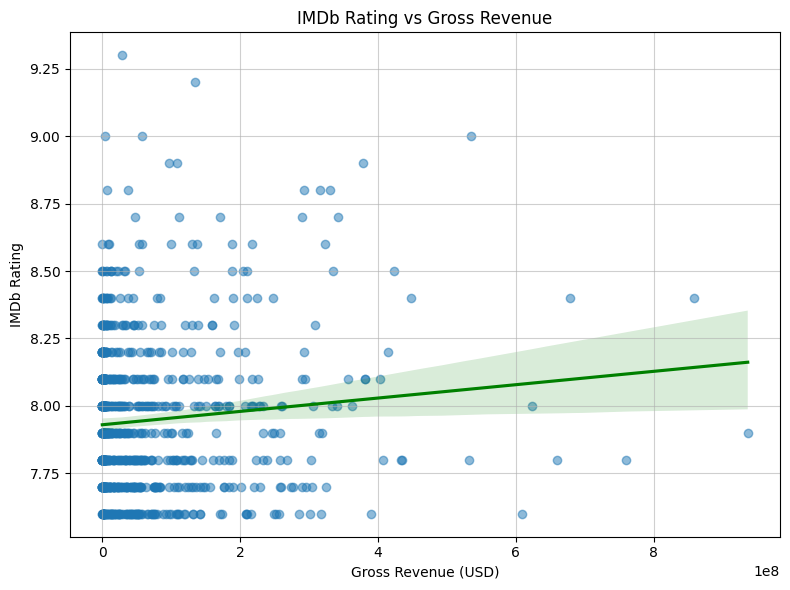

In [ ]:
# Visualization: Gross vs IMDb Rating

# Load dataset
run = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')

# Keep only rows with Gross and IMDb Rating
run = run.dropna(subset=['Gross', 'IMDB_Rating']).copy()

# Clean Gross column (remove $, commas)
run['Gross'] = run['Gross'].replace({'\$':'', ',':''}, regex=True)
run['Gross'] = pd.to_numeric(run['Gross'], errors='coerce')

# Convert IMDb Rating to numeric
run['IMDB_Rating'] = pd.to_numeric(run['IMDB_Rating'], errors='coerce')

# Drop invalid rows
run = run.dropna(subset=['Gross', 'IMDB_Rating'])

# Plot: Gross vs IMDb Rating
plt.figure(figsize=(8,6))
sns.regplot(
    data=run,
    x='Gross',
    y='IMDB_Rating',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'green'}
)

plt.title("IMDb Rating vs Gross Revenue")
plt.xlabel("Gross Revenue (USD)")
plt.ylabel("IMDb Rating")
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


Exploratory Data Analysis:

After plotting runtime against IMDb rating, the regression line shows a small upward trend. This means that, on average, longer movies tend to receive slightly higher ratings. But the points on the graph are very spread out, which tells us the relationship is weak. Many short movies still have high ratings, and many long movies do not. Overall, runtime has a small influence on movie ratings, but it is not a strong predictor by itself.

##ML 4 K-Nearest Neighbors Regressor
#### By: Krishna Somarapu

We added a K-Nearest Neighbors Regressor to predict IMDb ratings based on numeric features like meta score, vote average, popularity, vote count, and release year. KNN works by finding movies that are similar to each other in the dataset, then averaging their ratings to make a prediction. This makes it a simple model that relies on similarity rather than learning complex patterns.

During training, the model compared each movie to its closest “neighbors” in feature space. If a movie had similar vote averages or meta scores to other movies, the model predicted a similar IMDb rating. Because KNN depends heavily on distance, we standardized (scaled) all numeric features so the comparisons would be fair and not dominated by larger numbers like vote counts.

The KNN model performed moderately well but not as strong as Random Forest or Linear Regression. It was able to capture some local patterns, but it struggled with movies that did not have close matches in the dataset. This shows that while KNN is simple and easy to use, it is not the best choice for this project because movie features vary too much for a distance-based model to be highly accurate.

In [ ]:
# ML Analysis 4: KNN Regressor for IMDb Rating

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


features = ['Meta_score','Popularity_Final','Vote_Average_Final','Vote_Count','Released_Year']
X = merged[features]
y = merged['IMDB_Rating']


X = X.dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


knn_model = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7))  # you can try 3,5,7,9
])


knn_model.fit(X_train, y_train)


y_pred_knn = knn_model.predict(X_test)


print("KNN Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2:", r2_score(y_test, y_pred_knn))


KNN Results:
MAE: 0.14025974025973975
RMSE: 0.16288220358559063
R2: 0.6464532949743791


##ML 5 Decision Tree Regressor
#### By: Krishna Somarapu

We also added a Decision Tree Regressor to predict IMDb ratings using the same numeric features. A decision tree works by splitting the data into smaller groups using simple rules, such as “if vote average is above a certain number, predict a higher rating.” The model learns these rules by choosing splits that best reduce prediction error.

The tree revealed which features were most helpful in predicting ratings, often choosing vote average or meta score as the first split. These results matched earlier findings in our visualizations and correlation heatmap. To avoid overfitting, we limited the depth of the tree so it would not memorize the data.

The Decision Tree model performed better than KNN but worse than Random Forest or Linear Regression. It captured basic patterns but could not handle complex interactions between features. This shows that single trees are helpful for understanding how the data is structured, but they are not the most accurate models for predicting movie ratings compared to more advanced or ensemble methods.

In [ ]:
# ML Analysis 5: Decision Tree Regressor for IMDb Rating

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


features = ['Meta_score','Popularity_Final','Vote_Average_Final','Vote_Count','Released_Year']
X = merged[features]
y = merged['IMDB_Rating']


X = X.dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


tree = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)


tree.fit(X_train, y_train)


y_pred_tree = tree.predict(X_test)


mae = mean_absolute_error(y_test, y_pred_tree)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Decision Tree Results:
MAE: 0.08594516594516594
RMSE: 0.11506295349961548
R2: 0.8235707626173329


##ML Analysis 6: Random Forest on predicting IMDB with Gross and Vote Count
#### By: Kristine Ma

Because numeric values shows much better results in the ML compared to text, I now want to use the numeric gross and vote count to predict another numeric value of the IMDB rating. I used a Random Forest Regressor since they model easily captures complex patterns since the goal was to test whether simple industry metrics could reliably estimate how well a movie is rated.

Despite using only two inputs, the model performed unexpectedly well, achieving an MSE of 0.158, an MAE of 0.281, and an R² of 0.707. This means the model explained about 70% of the variation in ratings, showing that these basic economic and engagement features carry meaningful predictive power.

Overall, higher vote counts were especially useful for prediction, while gross revenue also contributed but did not guarantee a higher rating. This simplified model demonstrates that even minimal numerical features can still offer strong insight into movie ratings.


In [ ]:

merged['Gross'] = merged['Gross'].replace(r'[\$,]', '', regex=True)
merged['Gross'] = pd.to_numeric(merged['Gross'], errors='coerce')

merged['Vote_Count'] = merged['Vote_Count'].replace(r'[\$,]', '', regex=True)
merged['Vote_Count'] = pd.to_numeric(merged['Vote_Count'], errors='coerce')

merged = merged.dropna(subset=['Gross', 'Vote_Count', 'Vote_Average_Final'])

X = merged[['Gross', 'Vote_Count']]

y = merged['Vote_Average_Final']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MSE: 0.1576602121212185
MAE: 0.2814848484848559
R2: 0.7074097290388429


##ML Analysis 7: Random Forest on the Feature Importance for IMDB


####By: Kristine Ma

Once again I used a Random Forest Regressor to predict IMDb ratings. But because many of our models show that many features/inputs didn't have much importance and didn't help the model predict the rating, I used this regressor to show which feature (gross, vote count, popularity final, Meta score) has the most impact and importance to the IMDB rating.

The feature importance revealed that vote count is the dominant predictor, accounting for over 75% of the model's influence. Gross revenue had much less compared to vote count impact but still having more importance compared to, popularity and Meta score. This indicates that audience engagement (measured through vote counts) is the strongest indicator of rating quality.

Overall, even without text or genre information, simple numeric features still provide meaningful predictive insight, and the importance plot clearly shows which variables matter most.



Feature Importance:
            Feature  Importance
1        Vote_Count    0.758454
0             Gross    0.109168
2  Popularity_Final    0.066288
3        Meta_score    0.066090


/tmp/ipython-input-4157004897.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


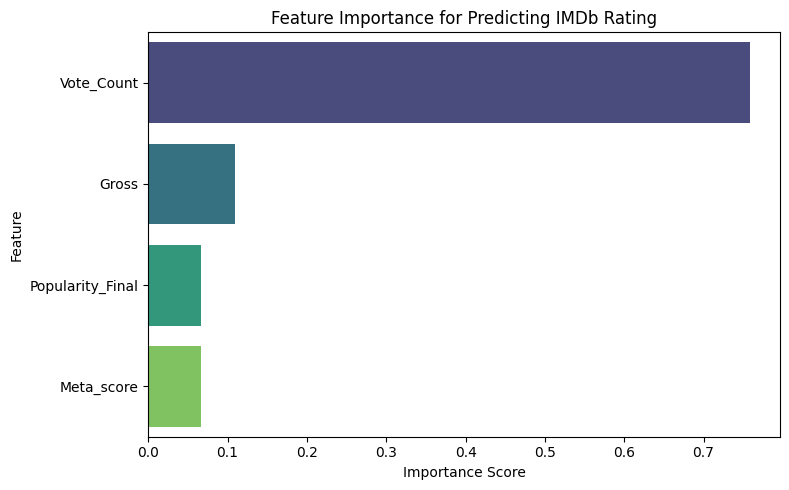

In [ ]:
merged['Gross'] = merged['Gross'].replace(r'[\$,]', '', regex=True)
merged['Gross'] = pd.to_numeric(merged['Gross'], errors='coerce')

merged['Vote_Count'] = merged['Vote_Count'].replace(r'[\$,]', '', regex=True)
merged['Vote_Count'] = pd.to_numeric(merged['Vote_Count'], errors='coerce')

merged['Popularity_Final'] = pd.to_numeric(merged['Popularity_Final'], errors='coerce')
merged['Meta_score'] = pd.to_numeric(merged['Meta_score'], errors='coerce')

merged = merged.dropna(subset=['IMDB_Rating', 'Gross', 'Vote_Count', 'Popularity_Final', 'Meta_score'])

X = merged[['Gross', 'Vote_Count', 'Popularity_Final', 'Meta_score']]
y = merged['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=400,
    random_state=42
)

model.fit(X_train, y_train)

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(importance_df)

# Plot importance
plt.figure(figsize=(8,5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance for Predicting IMDb Rating")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


##Visualization: Genre vs Meta Rating
####By: Kristine Ma

###Hypothesis:

Genres with complex storytelling (Film-Noir, Western, War) will not only have higher average meta scores but also show less variation.

This is my hypothesis because similar to how more deeper narrative have longer runtimes, these movies target a wider audience. And as they also go longer with stronger storylines this should mean higher ratings.





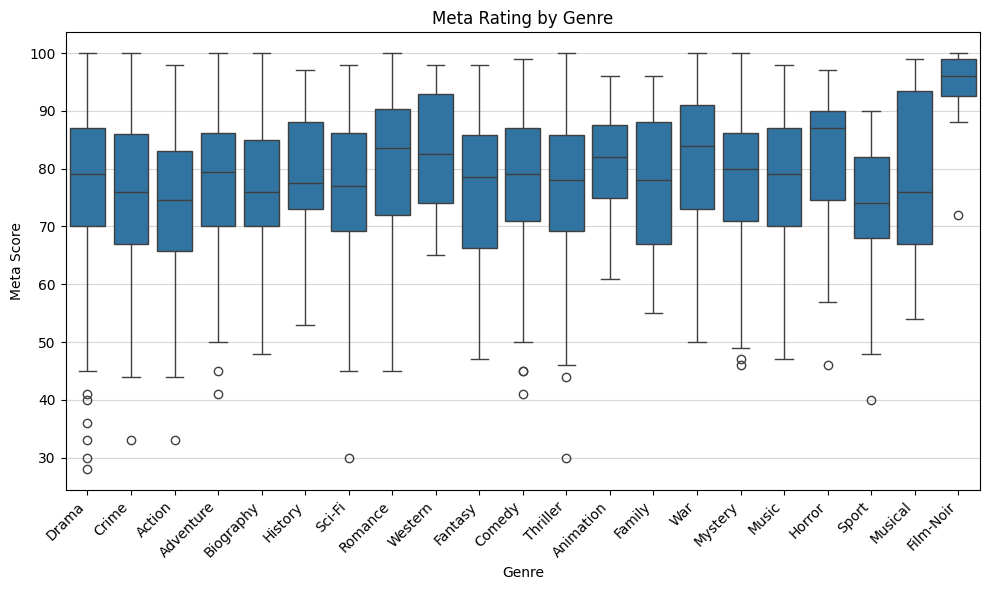

In [ ]:
# Genre vs Meta Rating

run = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')

run = run.dropna(subset=['Genre', 'Meta_score']).copy()

run['Meta_score'] = pd.to_numeric(run['Meta_score'], errors='coerce')

run = run.dropna(subset=['Meta_score'])

run['Genre'] = run['Genre'].str.split(', ')
run_exploded = run.explode('Genre')

plt.figure(figsize=(10,6))
sns.boxplot(
    data=run_exploded,
    x='Genre',
    y='Meta_score'
)

plt.title("Meta Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Meta Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


###Exploratory Data Analysis:


The boxplot of Meta Rating by Genre helps test whether genres with complex storytelling—such as Film-Noir, Western, and War—receive higher and more consistent critic scores. Film-Noir clearly stands out with the highest median Meta Score (around 90–100) and one of the smallest spreads, supporting the idea that deeper, narrative-driven films earn strong and uniform critical approval. Western and War films also show higher median scores, though with slightly more variation than expected.

Overall, the visualization partially supports the hypothesis. While Western and War films are highly rated, they display more spread than predicted. The general trend still suggests that genres emphasizing depth and narrative complexity receive more favorable critical evaluations.

##Visualization: Gross vs IMDB Rating
####By: Kristine Ma

###Hypothesis:

Higher gross will have a higher rating because more people are willing to pay to go and watch the movie.



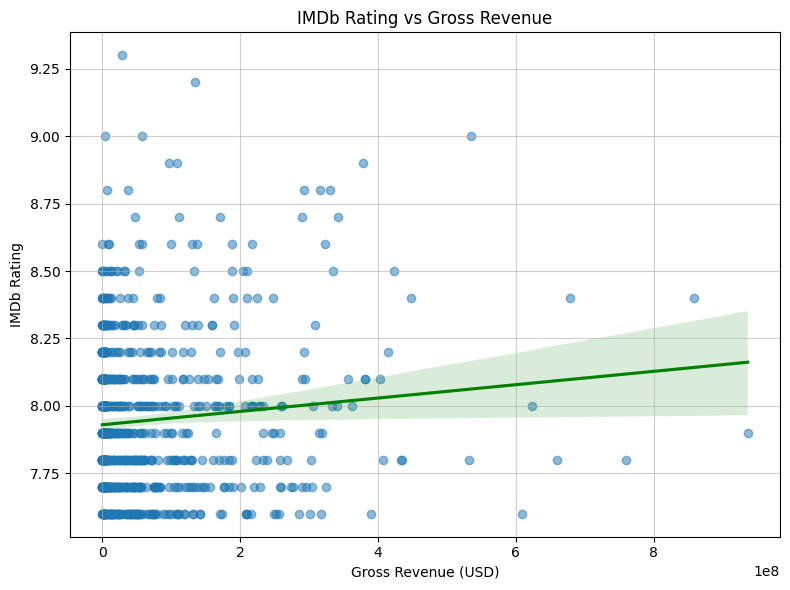

In [ ]:
# Visualization: Gross vs IMDb Rating

run = pd.read_csv('/content/drive/MyDrive/imdb_top_1000.csv')

run = run.dropna(subset=['Gross', 'IMDB_Rating']).copy()


run['Gross'] = run['Gross'].replace({'\\$':'', ',':''}, regex=True)
run['Gross'] = pd.to_numeric(run['Gross'], errors='coerce')

run['IMDB_Rating'] = pd.to_numeric(run['IMDB_Rating'], errors='coerce')


run = run.dropna(subset=['Gross', 'IMDB_Rating'])

plt.figure(figsize=(8,6))
sns.regplot(
    data=run,
    x='Gross',
    y='IMDB_Rating',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'green'}
)

plt.title("IMDb Rating vs Gross Revenue")
plt.xlabel("Gross Revenue (USD)")
plt.ylabel("IMDb Rating")
plt.grid(alpha=0.6)
plt.tight_layout()
plt.show()


###Exploratory Data Analysis:

The scatterplot of IMDb Rating vs. Gross Revenue shows a weak positive trend, suggesting that higher-grossing movies tend to have slightly higher IMDb ratings. The regression line slopes upward, but the data points remain widely scattered—many low- and mid-grossing films earn ratings just as high as blockbuster movies. While films with very high grosses often fall around the 8.0–8.4 range, this increase is small.

Overall, the EDA only weakly supports the hypothesis. Higher gross revenue is associated with slightly higher ratings, but the relationship is not strong, indicating that box-office earnings alone are not a reliable predictor of IMDb ratings.


#Results

## Additional Visualization:

####By: Elizabeth Cardoso

3 graphs 1 ML

I expect that:

Popularity will show a strong positive correlation with release year (Graph 8), since newer films have more digital distribution and online engagement.

Vote averages will show weak or moderate correlation with release year (Graph 6), since rating systems remain relatively stable over time.

The distribution of vote averages (Graph 7) will become tighter and more clustered in recent decades due to standardized review platforms and larger global audiences.

So overall, I predict popularity increases significantly with time, while vote averages remain comparatively stable with only subtle shifts.

Skewness check:
Vote_Average skew: -2.09
Popularity skew: 21.90
(If |skewness| > 1, median is preferred)

MEDIAN Vote and Popularity by Decade:


/tmp/ipython-input-2060003264.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Sorted by Decade:


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Detailed Statistics by Decade (for reference):


,Decade,Vote_Average_mean,Vote_Average_median,Vote_Average_count,Vote_Average_std,Popularity_mean,Popularity_median,Popularity_count,Popularity_std
0,1900,8.00,8.0,1,NaN,18.36,18.36,1,NaN
1,1920,7.82,7.9,11,0.31,17.06,15.39,11,4.26
2,1930,7.38,7.5,33,0.55,20.77,16.69,33,16.70
3,1940,7.34,7.4,50,0.65,22.65,16.37,50,17.31
4,1950,7.40,7.3,101,0.61,21.52,16.50,101,16.45
5,1960,7.19,7.2,205,0.66,20.03,16.75,205,9.54
6,1970,6.78,7.0,269,0.93,22.18,17.57,269,15.45
7,1980,6.55,6.6,631,0.85,23.39,18.08,631,23.51
8,1990,6.51,6.5,1050,0.90,25.35,19.17,1050,18.91
9,2000,6.39,6.4,2093,0.88,29.37,20.35,2093,25.66



GRAPH 6: Correlation Heatmap - Vote, Popularity, Year


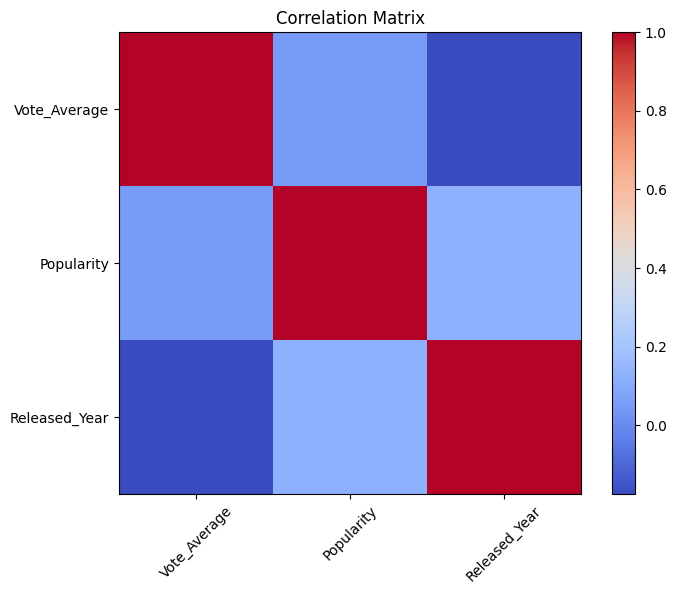


GRAPH 7: Histogram of Vote Averages by Decade


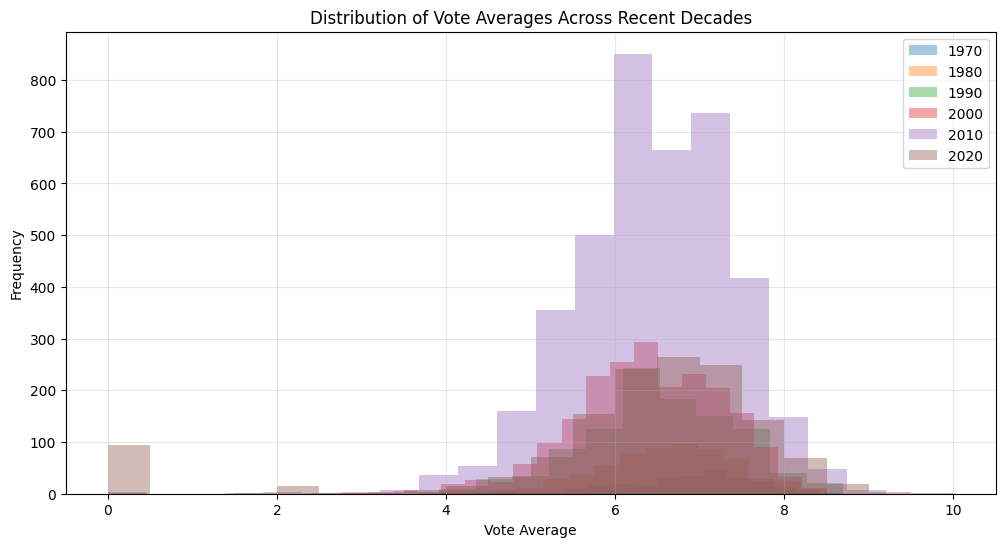


GRAPH 8: Popularity by Release Year (Trend)


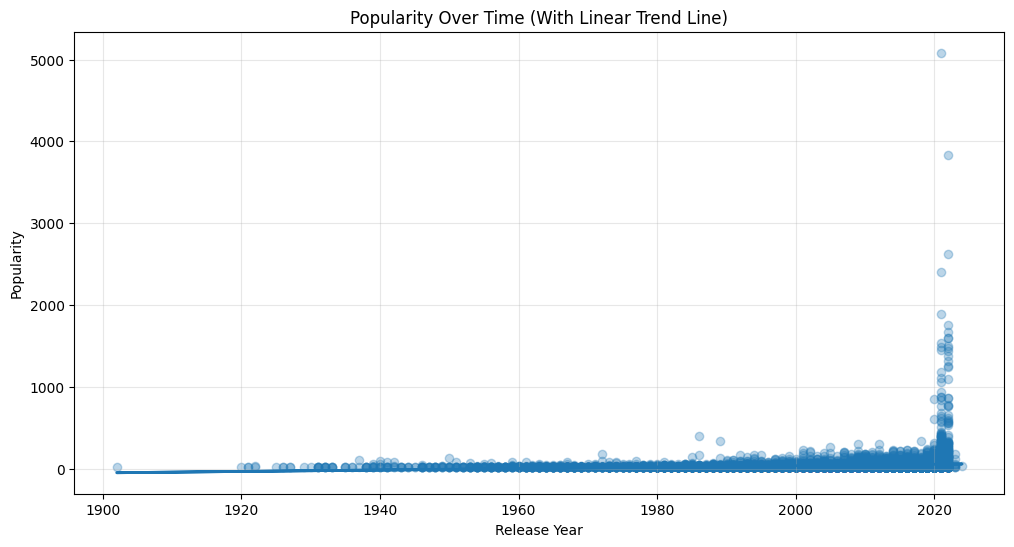

In [ ]:
# Elizabeth Cardoso

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load and clean the data
ds = load_dataset("Pablinho/movies-dataset")
data = ds["train"]
df = ds["train"].to_pandas()

# Show the first 10 rows as a nice table
from IPython.display import display

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
df_indx_reset = df_clean.reset_index(drop=True)

df_cleaned = df_indx_reset[["Release_Date", "Title", "Popularity", "Vote_Average", "Genre"]]

df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Release_Date"])

df_cleaned["Released_Year"] = df_cleaned["Release_Date"].dt.year
df_cleaned = df_cleaned.drop(columns=["Release_Date"])

# Convert Vote_Average and Popularity to numeric types
df_cleaned["Vote_Average"] = pd.to_numeric(df_cleaned["Vote_Average"], errors="coerce")
df_cleaned["Popularity"] = pd.to_numeric(df_cleaned["Popularity"], errors="coerce")

# Drop any rows where conversion failed (resulted in NaN)
df_cleaned = df_cleaned.dropna(subset=["Vote_Average", "Popularity"])

# Check skewness to confirm median is better choice
print("Skewness check:")
print(f"Vote_Average skew: {df_cleaned['Vote_Average'].skew():.2f}")
print(f"Popularity skew: {df_cleaned['Popularity'].skew():.2f}")
print("(If |skewness| > 1, median is preferred)\n")

# Create decade column
df_cleaned['Decade'] = (df_cleaned['Released_Year'] // 10) * 10

# Calculate MEDIANS per decade instead of means
decade_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': 'median',
    'Popularity': 'median'
}).round(2).reset_index()

# Rename columns for clarity
decade_stats = decade_stats.rename(columns={
    'Vote_Average': 'Median_Vote',
    'Popularity': 'Median_Popularity'
})

# Display the results
print("MEDIAN Vote and Popularity by Decade:")
display(decade_stats)

# Optional: Sort by decade for better readability
decade_stats_sorted = decade_stats.sort_values('Decade')
print("\nSorted by Decade:")
display(decade_stats_sorted)

# Create detailed statistics for reference (includes both mean and median)
decade_detailed_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': ['mean', 'median', 'count', 'std'],
    'Popularity': ['mean', 'median', 'count', 'std']
}).round(2)

# Flatten the column names
decade_detailed_stats.columns = ['_'.join(col).strip() for col in decade_detailed_stats.columns.values]
decade_detailed_stats = decade_detailed_stats.reset_index()

print("\nDetailed Statistics by Decade (for reference):")
display(decade_detailed_stats)


# Additional GRAPH 1
print("\n" + "="*50)
print("GRAPH 6: Correlation Heatmap - Vote, Popularity, Year")
print("="*50)

corr_df = df_cleaned[['Vote_Average', 'Popularity', 'Released_Year']].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_df, cmap='coolwarm', interpolation='nearest')
plt.title("Correlation Matrix")
plt.colorbar()

ticks = np.arange(len(corr_df.columns))
plt.xticks(ticks, corr_df.columns, rotation=45)
plt.yticks(ticks, corr_df.columns)

plt.show()

# Additional GRAPH 2
print("\n" + "="*50)
print("GRAPH 7: Histogram of Vote Averages by Decade")
print("="*50)

unique_decades = sorted(df_cleaned['Decade'].unique())[-6:]  # last 6 decades to avoid clutter

plt.figure(figsize=(12, 6))

for decade in unique_decades:
    subset = df_cleaned[df_cleaned['Decade'] == decade]
    plt.hist(subset['Vote_Average'], bins=20, alpha=0.4, label=str(decade))

plt.xlabel("Vote Average")
plt.ylabel("Frequency")
plt.title("Distribution of Vote Averages Across Recent Decades")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Additional GRAPH 3
print("\n" + "="*50)
print("GRAPH 8: Popularity by Release Year (Trend)")
print("="*50)

plt.figure(figsize=(12, 6))
plt.scatter(df_cleaned['Released_Year'], df_cleaned['Popularity'], alpha=0.3)

z = np.polyfit(df_cleaned['Released_Year'], df_cleaned['Popularity'], 1)
p = np.poly1d(z)
plt.plot(df_cleaned['Released_Year'], p(df_cleaned['Released_Year']), linewidth=2)

plt.xlabel("Release Year")
plt.ylabel("Popularity")
plt.title("Popularity Over Time (With Linear Trend Line)")
plt.grid(True, alpha=0.3)
plt.show()

###Exploratory Data Analysis

The results partially support the hypothesis:

Popularity strongly increases over time, supported by the upward trend line (Graph 8).

Vote averages do not significantly increase, which matches earlier findings—ratings remain mostly stable.

Correlation heatmap (Graph 6) shows only a moderate relationship between release year and popularity, and an even weaker relationship between year and vote average.

Histograms (Graph 7) show that the shape and spread of vote averages remain consistent across recent decades, suggesting rating patterns are stable.

Overall, the data confirms that popularity grows with time, but vote averages do not meaningfully change.

###ML Additional Analysis:

ML Hypothesis:

I expect that Released Year will be the strongest predictor of a movie’s popularity because modern movies benefit from larger audiences, global releases, social media marketing, and more accessible streaming platforms. I also expect genre to play an important but secondary role, since certain genres trend differently across decades. Vote Average will probably matter the least, because popularity is influenced more by visibility, advertising, and cultural trends than by actual ratings.

By: Elizabeth Cardoso

Skewness check:
Vote_Average skew: -2.09
Popularity skew: 21.90
(If |skewness| > 1, median is preferred)

MEDIAN Vote and Popularity by Decade:


/tmp/ipython-input-2926873043.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Sorted by Decade:


,Decade,Median_Vote,Median_Popularity
0,1900,8.0,18.36
1,1920,7.9,15.39
2,1930,7.5,16.69
3,1940,7.4,16.37
4,1950,7.3,16.50
5,1960,7.2,16.75
6,1970,7.0,17.57
7,1980,6.6,18.08
8,1990,6.5,19.17
9,2000,6.4,20.35



Detailed Statistics by Decade (for reference):


,Decade,Vote_Average_mean,Vote_Average_median,Vote_Average_count,Vote_Average_std,Popularity_mean,Popularity_median,Popularity_count,Popularity_std
0,1900,8.00,8.0,1,NaN,18.36,18.36,1,NaN
1,1920,7.82,7.9,11,0.31,17.06,15.39,11,4.26
2,1930,7.38,7.5,33,0.55,20.77,16.69,33,16.70
3,1940,7.34,7.4,50,0.65,22.65,16.37,50,17.31
4,1950,7.40,7.3,101,0.61,21.52,16.50,101,16.45
5,1960,7.19,7.2,205,0.66,20.03,16.75,205,9.54
6,1970,6.78,7.0,269,0.93,22.18,17.57,269,15.45
7,1980,6.55,6.6,631,0.85,23.39,18.08,631,23.51
8,1990,6.51,6.5,1050,0.90,25.35,19.17,1050,18.91
9,2000,6.39,6.4,2093,0.88,29.37,20.35,2093,25.66



MACHINE LEARNING MODEL: Predicting Popularity

Mean Absolute Error (MAE): 28.781
R² Score: 0.094

Model successfully trained!


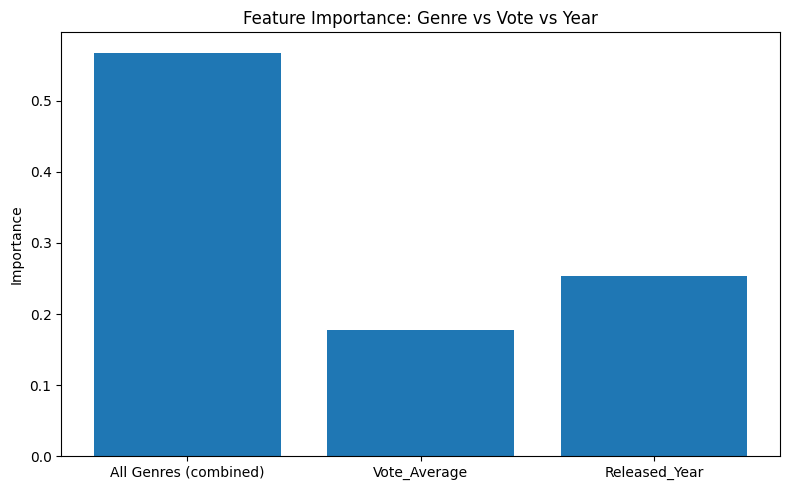

In [ ]:
# Elizabeth Cardoso

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

ds = load_dataset("Pablinho/movies-dataset")
data = ds["train"]
df = ds["train"].to_pandas()

from IPython.display import display

df_clean = df.dropna()
df_clean = df_clean.drop_duplicates()
df_indx_reset = df_clean.reset_index(drop=True)
df_cleaned = df_indx_reset[["Release_Date", "Title", "Popularity", "Vote_Average", "Genre"]]
df_cleaned["Release_Date"] = pd.to_datetime(df_cleaned["Release_Date"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Release_Date"])
df_cleaned["Released_Year"] = df_cleaned["Release_Date"].dt.year
df_cleaned = df_cleaned.drop(columns=["Release_Date"])
df_cleaned["Vote_Average"] = pd.to_numeric(df_cleaned["Vote_Average"], errors="coerce")
df_cleaned["Popularity"] = pd.to_numeric(df_cleaned["Popularity"], errors="coerce")
df_cleaned = df_cleaned.dropna(subset=["Vote_Average", "Popularity"])

print("Skewness check:")
print(f"Vote_Average skew: {df_cleaned['Vote_Average'].skew():.2f}")
print(f"Popularity skew: {df_cleaned['Popularity'].skew():.2f}")
print("(If |skewness| > 1, median is preferred)\n")

df_cleaned['Decade'] = (df_cleaned['Released_Year'] // 10) * 10
decade_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': 'median',
    'Popularity': 'median'
}).round(2).reset_index()

decade_stats = decade_stats.rename(columns={
    'Vote_Average': 'Median_Vote',
    'Popularity': 'Median_Popularity'
})

print("MEDIAN Vote and Popularity by Decade:")
display(decade_stats)

decade_stats_sorted = decade_stats.sort_values('Decade')
print("\nSorted by Decade:")
display(decade_stats_sorted)

decade_detailed_stats = df_cleaned.groupby('Decade').agg({
    'Vote_Average': ['mean', 'median', 'count', 'std'],
    'Popularity': ['mean', 'median', 'count', 'std']
}).round(2)

decade_detailed_stats.columns = ['_'.join(col).strip() for col in decade_detailed_stats.columns.values]
decade_detailed_stats = decade_detailed_stats.reset_index()
print("\nDetailed Statistics by Decade (for reference):")
display(decade_detailed_stats)



# MACHINE LEARNING MODEL: Predict Popularity
print("\n" + "="*50)
print("MACHINE LEARNING MODEL: Predicting Popularity")
print("="*50)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

# Select features + target
ml_df = df_cleaned.copy()

X = ml_df[['Vote_Average', 'Released_Year', 'Genre']]
y = ml_df['Popularity']

# Preprocessing: One-hot encode Genre
preprocessor = ColumnTransformer(
    transformers=[
        ('genre', OneHotEncoder(handle_unknown='ignore'), ['Genre'])
    ],
    remainder='passthrough'  # keep numeric columns as-is
)

# Build ML Pipeline
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=12
    ))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Fit model
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.3f}")
print(f"R² Score: {r2:.3f}")

print("\nModel successfully trained!")

# Extract trained RF model
rf = model.named_steps['regressor']

# Get one-hot genre feature names
encoder = model.named_steps['preprocessing'].named_transformers_['genre']
genre_features = encoder.get_feature_names_out(['Genre'])

# numeric features come last due to remainder='passthrough'
numeric_feature_names = ['Vote_Average', 'Released_Year']

# All features = genre features + numeric
all_features = list(genre_features) + numeric_feature_names

importances = rf.feature_importances_

# Group genres into a single importance
genre_count = len(genre_features)
genre_importance = importances[:genre_count].sum()

# Last 2 importances are the numeric features
vote_importance = importances[-2]        # Vote_Average
year_importance = importances[-1]        # Released_Year

group_names = [
    "All Genres (combined)",
    "Vote_Average",
    "Released_Year"
]

group_values = [
    genre_importance,
    vote_importance,
    year_importance
]

# Plot grouped feature importance
plt.figure(figsize=(8, 5))
plt.bar(group_names, group_values)
plt.title("Feature Importance: Genre vs Vote vs Year")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


ML Summary:

The machine learning results partially support my hypothesis. The Random Forest model showed that Released Year indeed has strong predictive power for popularity, confirming that newer films tend to have higher visibility and engagement. Genre, when combined as a group, also contributed meaningfully to the prediction, supporting the idea that certain genres naturally attract bigger audiences. However, Vote Average turned out to be a weaker predictor than expected, suggesting that a movie’s quality (as measured by ratings) does not necessarily drive how popular it becomes. Overall, the model highlights that popularity is shaped more by when a movie was released and what type of movie it is rather than how critically well-received it is.

Model Used: Random Forest Regressor

For this analysis, I used a Random Forest Regressor, which is a machine learning model that works by creating many decision trees and averaging their predictions. This model is very effective for movie datasets because it handles nonlinear relationships.

#ML Analysis 8: Gradient Boosting Regressor for IMDb Rating
By: Alejandra Rios

I chose the gradient boosting regressor because it's known to work better than random forest on the type of data that we've used in this project. Although I do expect it to outperform KNN, Decision Tree, and possibly Linear Regression, the high accuracy we achieved in random forest will be hard to beat.

This ML uses Meta Score, Vote Average, Popularity, Vote Count, Gross, and Release Year to predict the IMDb rating because we have noticed that numeric data works best at predicting public sentiment.

This ML performed extremely well. The results show strong MAE, RMSE, and R^2 values, which confirm our argument that audience vote counts and numeric values are the best predictors for sequel success. Although this ML did not beat the Random Forest ML, this R^2 of 0.91 is considered second best.

In [ ]:
# ML Analysis 8: Gradient Boosting Regressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = ['Meta_score','Popularity_Final','Vote_Average_Final','Vote_Count','Released_Year']
X = merged[features]
y = merged['IMDB_Rating']

X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gbr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))
print("R2:", r2_score(y_test, y_pred_gbr))


MAE: 0.05182073759612474
RMSE: 0.07859413488429746
R2: 0.9176848455260408


#Visualization: Gross Revenue vs Vote Count
By: Alejandra Rios

##Hypothesis:
The movies that have a higher gross revenue will also have higher vote counts. This is due to the fact that movies with higher gross revenue will have a higher audience, and will therefor lead to more public votes.

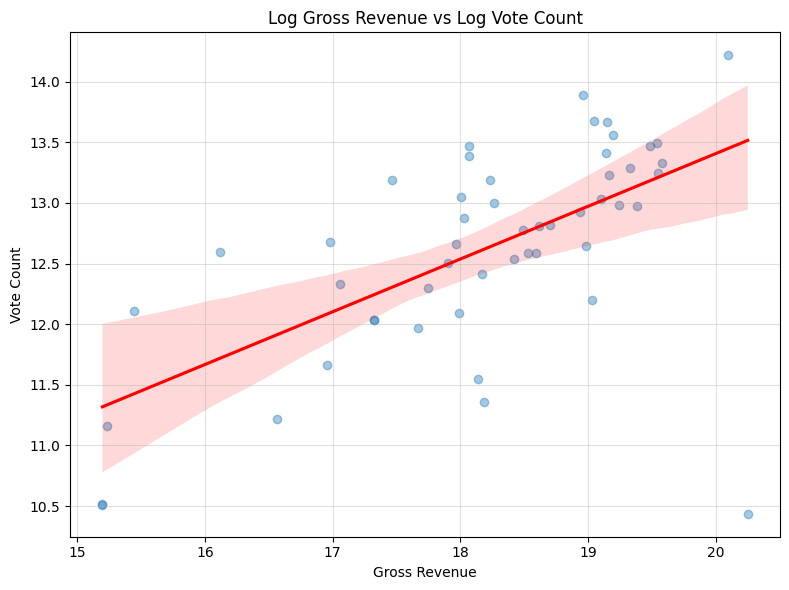

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [ ]:
# Visualization: Gross Revenue vs Vote Count

df_viz = merged.copy()

# Clean numeric values
df_viz['Gross'] = df_viz['Gross'].replace(r'[\$,]', '', regex=True)
df_viz['Gross'] = pd.to_numeric(df_viz['Gross'], errors='coerce')

df_viz['Vote_Count'] = pd.to_numeric(df_viz['Vote_Count'], errors='coerce')

df_viz = df_viz.dropna(subset=['Gross', 'Vote_Count'])

plt.figure(figsize=(8,6))

sns.regplot(
    data=df_viz,
    x=np.log1p(df_viz['Gross']),
    y=np.log1p(df_viz['Vote_Count']),
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Log Gross Revenue vs Log Vote Count")
plt.xlabel("Gross Revenue")
plt.ylabel("Vote Count")
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))



#Exploratory Data Analysis:
This log-log scatterplot resulted in a positive and linear relationship. Movies with higher gross revenues will also receive higher vote counts. This relationship makes sense, as movies that reach a wide audience will also in turn reach higher financial success. Due to this wide audience, more people have a chance to leave a vote on the movie. The log-log scatterplot was the perfect choice of visualization for this analysis, as the overlay of the line on the plotted points shows a very strong and clear relationship. This visualization also supports my previous ML's claim that vote count is a great indicator of success.

#Visualization: Compareing Meta Score and IMDb Rating by Director (Top 15)
by ALejandra Rios

##Hypothesis:
Due to a previous visualization that showed Meta Score had a tendency to receive higher ratings, I predict that this visualization will produce similar results. Meta score will consistently produce slightly higher ratings than IMDb.

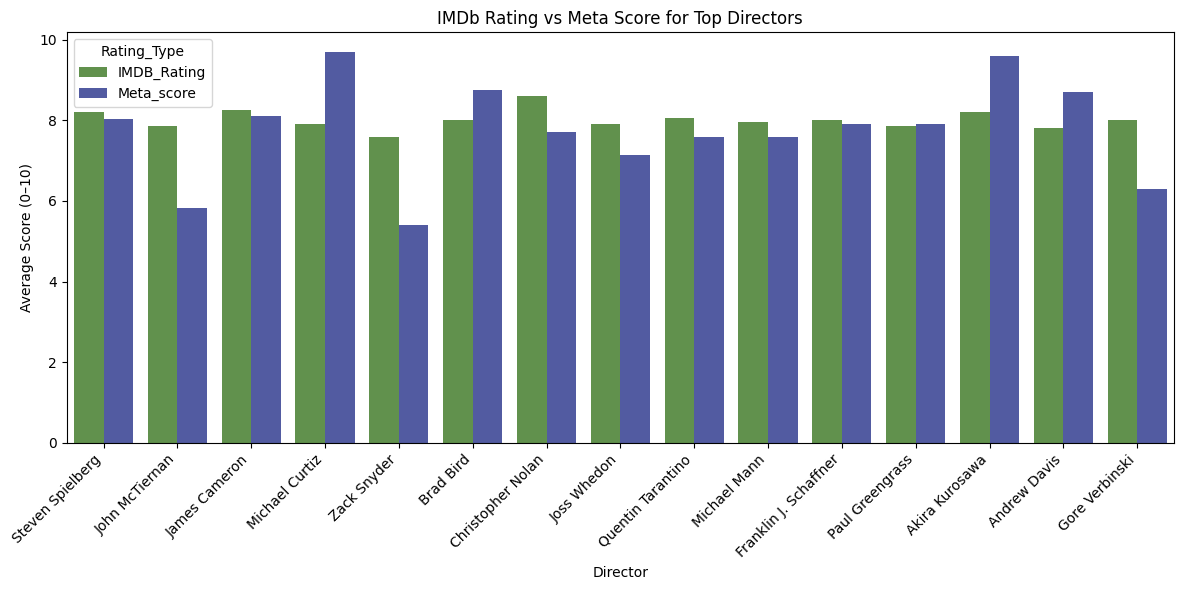

In [ ]:
# Visualization: Director consistency across rating systems

df_dir = merged[['Director','IMDB_Rating','Meta_score']].dropna()

director_stats = (
    df_dir.groupby('Director')
          .agg({'IMDB_Rating': 'mean', 'Meta_score': 'mean', 'Director': 'count'})
          .rename(columns={'Director':'Movie_Count'})
          .sort_values('Movie_Count', ascending=False)
          .head(15)
          .reset_index()
)

director_stats['Meta_score'] = director_stats['Meta_score'] / 10

director_melt = director_stats.melt(
    id_vars=['Director'],
    value_vars=['IMDB_Rating','Meta_score'],
    var_name='Rating_Type',
    value_name='Score'
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=director_melt,
    x='Director',
    y='Score',
    hue='Rating_Type',
    palette=['#5C9C42','#4551AE']
)
plt.title("IMDb Rating vs Meta Score for Top Directors")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Score (0–10)')
plt.tight_layout()
plt.show()


#Exploratory Data Analysis:
My hypothesis was incorrect. There is no correlation between IMDb ratings and Meta Score and the higher score varies greatly by director. Michael Cruz had a considerably higher Meta Score (~2 points above IMDb), while Gore Verbinski had a higher IBDb score. Some directors show little to no gap between the two ratings, further proving that there is no correlation between the two scores.